In [ ]:
# ============================================================
# CELL 1 — MOBILE NET V4
# INSTALL & IMPORT REQUIRED LIBRARIES
# ============================================================

# Install timm for MobileNetV4
!pip install -q timm

# ------------------------------------------------------------
# IMPORTS
# ------------------------------------------------------------

import os
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, transforms

import timm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# DEVICE
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 75)
print("MOBILENETV4 IMPLEMENTATION")
print("=" * 75)

print("\nPyTorch version :", torch.__version__)
print("Torchvision version :", torchvision.__version__)
print("timm version :", timm.__version__)
print("Device :", device)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
else:
    print("GPU : CPU")

print("=" * 75)

MOBILENETV4 IMPLEMENTATION

PyTorch version : 2.11.0+cu128
Torchvision version : 0.26.0+cu128
timm version : 1.0.29
Device : cuda
GPU : Tesla T4


In [ ]:
# ============================================================
# CELL 2 — CONFIGURATION & DATASET PATHS
# ============================================================

# ------------------------------------------------------------
# RANDOM SEED
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# DATASET PATH
# ------------------------------------------------------------

DATASET_PATH = "/kaggle/input/indian-painting-dataset"


# ------------------------------------------------------------
# TRAIN / VALIDATION DIRECTORIES
# ------------------------------------------------------------

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VAL_DIR   = os.path.join(DATASET_PATH, "val")


# ------------------------------------------------------------
# MODEL CONFIGURATION
# ------------------------------------------------------------

MODEL_NAME = "mobilenetv4_conv_small"

NUM_CLASSES = 8

IMAGE_SIZE = 224


# ------------------------------------------------------------
# TRAINING CONFIGURATION
# ------------------------------------------------------------

BATCH_SIZE = 32

NUM_WORKERS = 2

STAGE1_EPOCHS = 10

STAGE2_EPOCHS = 15


# ------------------------------------------------------------
# OPTIMIZATION
# ------------------------------------------------------------

STAGE1_LR = 1e-3

STAGE2_LR = 1e-4

WEIGHT_DECAY = 1e-4


# ------------------------------------------------------------
# OUTPUT / SAVE PATH
# ------------------------------------------------------------

SAVE_DIR = "/content/drive/MyDrive/Iconography/Implementation/MobileNet-V4"

os.makedirs(SAVE_DIR, exist_ok=True)


# ------------------------------------------------------------
# PRINT CONFIGURATION
# ------------------------------------------------------------

print("=" * 75)
print("MOBILENETV4 — EXPERIMENT CONFIGURATION")
print("=" * 75)

print("\nDataset path        :", DATASET_PATH)
print("Train directory     :", TRAIN_DIR)
print("Validation directory:", VAL_DIR)

print("\nModel               :", MODEL_NAME)
print("Number of classes   :", NUM_CLASSES)
print("Image size          :", IMAGE_SIZE)

print("\nBatch size          :", BATCH_SIZE)
print("Stage 1 epochs      :", STAGE1_EPOCHS)
print("Stage 2 epochs      :", STAGE2_EPOCHS)

print("\nStage 1 learning rate:", STAGE1_LR)
print("Stage 2 learning rate:", STAGE2_LR)
print("Weight decay        :", WEIGHT_DECAY)

print("\nSave directory      :", SAVE_DIR)

print("=" * 75)

MOBILENETV4 — EXPERIMENT CONFIGURATION

Dataset path        : /kaggle/input/indian-painting-dataset
Train directory     : /kaggle/input/indian-painting-dataset/train
Validation directory: /kaggle/input/indian-painting-dataset/val

Model               : mobilenetv4_conv_small
Number of classes   : 8
Image size          : 224

Batch size          : 32
Stage 1 epochs      : 10
Stage 2 epochs      : 15

Stage 1 learning rate: 0.001
Stage 2 learning rate: 0.0001
Weight decay        : 0.0001

Save directory      : /content/drive/MyDrive/Iconography/Implementation/MobileNet-V4


In [ ]:
# ============================================================
# CELL 2 — DOWNLOAD DATASET USING KAGGLEHUB
# ============================================================

# Install KaggleHub
!pip -q install kagglehub

import kagglehub


# ------------------------------------------------------------
# DOWNLOAD DATASET
# ------------------------------------------------------------

print("=" * 75)
print("DOWNLOADING INDIAN PAINTINGS DATASET")
print("=" * 75)

dataset_path = kagglehub.dataset_download(
    "ajg117/indian-paintings-dataset"
)

print("\nDataset downloaded successfully!")
print("Dataset path:")
print(dataset_path)


# ------------------------------------------------------------
# SHOW DATASET CONTENTS
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("DATASET CONTENTS")
print("=" * 75)

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)

    if level <= 2:
        indent = "    " * level
        print(f"{indent}{os.path.basename(root)}/")

        for file in files[:5]:
            print(f"{indent}    {file}")

print("=" * 75)


# ------------------------------------------------------------
# MODEL CONFIGURATION
# ------------------------------------------------------------

MODEL_NAME = "mobilenetv4_conv_small"

NUM_CLASSES = 8

IMAGE_SIZE = 224


# ------------------------------------------------------------
# TRAINING CONFIGURATION
# ------------------------------------------------------------

BATCH_SIZE = 32

NUM_WORKERS = 2

STAGE1_EPOCHS = 10

STAGE2_EPOCHS = 15


# ------------------------------------------------------------
# LEARNING RATES
# ------------------------------------------------------------

STAGE1_LR = 1e-3

STAGE2_LR = 1e-4

WEIGHT_DECAY = 1e-4


# ------------------------------------------------------------
# OUTPUT DIRECTORY
# ------------------------------------------------------------

SAVE_DIR = "/content/drive/MyDrive/Iconography/Implementation/MobileNet-V4"

os.makedirs(SAVE_DIR, exist_ok=True)


# ------------------------------------------------------------
# RANDOM SEED
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


print("\n" + "=" * 75)
print("CONFIGURATION READY")
print("=" * 75)

print("\nModel             :", MODEL_NAME)
print("Number of classes :", NUM_CLASSES)
print("Image size        :", IMAGE_SIZE)
print("Batch size        :", BATCH_SIZE)

print("\nStage 1 epochs    :", STAGE1_EPOCHS)
print("Stage 2 epochs    :", STAGE2_EPOCHS)

print("\nStage 1 LR        :", STAGE1_LR)
print("Stage 2 LR        :", STAGE2_LR)
print("Weight decay      :", WEIGHT_DECAY)

print("\nSave directory    :", SAVE_DIR)

print("=" * 75)

DOWNLOADING INDIAN PAINTINGS DATASET


100%|██████████| 355M/355M [00:21<00:00, 17.7MB/s]

Extracting files...



Dataset downloaded successfully!
Dataset path:
/root/.cache/kagglehub/datasets/ajg117/indian-paintings-dataset/versions/3

DATASET CONTENTS
3/
    classes.csv
    LICENSE
    mandana art drawing/
        mandana36.jpg
        mandana23.jpg
        mandana104.jpeg
        mandana41.jpg
        mandana52.png
    kangra painting/
        kangra53.jpg
        kangra86.jpg
        kangra63.jpeg
        kangra16.jpg
        kangra74.jpeg
    madhubani painting/
        madhubani19.jpg
        madhubani58.png
        madhubani14.jpeg
        madhubani87.webp
        madhubani24.png
    warli painting/
        warli26.jpg
        warli62.png
        warli28.jpg
        1697527573497.jpg
        warli44.jpg
    pichwai painting/
        pichwai60.jpg
        pichwai48.jpg
        pichwai64.jpg
        pichwai62.jpg
        pichwai35.png
    gond painting/
        gond99.png
        gond93.jpg
        gond66.jpg
        gond77.jpg
        gond28.jpg
    kerala mural/
        kerala86.webp
     

In [ ]:
# ============================================================
# CELL 3 — DATASET STRUCTURE & CLASS DISCOVERY
# ============================================================

print("=" * 75)
print("ANALYZING DOWNLOADED DATASET")
print("=" * 75)


# ------------------------------------------------------------
# FIND ALL DIRECTORIES
# ------------------------------------------------------------

all_dirs = []

for root, dirs, files in os.walk(dataset_path):
    for directory in dirs:
        all_dirs.append(os.path.join(root, directory))


print("\nDirectories found:")
for directory in all_dirs:
    print(" -", directory)


# ------------------------------------------------------------
# FIND IMAGE FILES
# ------------------------------------------------------------

IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
)

image_files = []

for root, dirs, files in os.walk(dataset_path):
    for file_name in files:
        if file_name.lower().endswith(IMAGE_EXTENSIONS):
            image_files.append(
                os.path.join(root, file_name)
            )


print("\n" + "=" * 75)
print("IMAGE INFORMATION")
print("=" * 75)

print("\nTotal image files found:", len(image_files))


# ------------------------------------------------------------
# SHOW SAMPLE IMAGE PATHS
# ------------------------------------------------------------

print("\nSample image paths:")

for image_path in image_files[:10]:
    print(" -", image_path)


# ------------------------------------------------------------
# ANALYZE TOP-LEVEL STRUCTURE
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("TOP-LEVEL DATASET STRUCTURE")
print("=" * 75)

for item in sorted(os.listdir(dataset_path)):

    full_path = os.path.join(dataset_path, item)

    if os.path.isdir(full_path):

        # Count images inside this directory
        count = 0

        for root, dirs, files in os.walk(full_path):
            for file_name in files:
                if file_name.lower().endswith(IMAGE_EXTENSIONS):
                    count += 1

        print(f"{item:<35} : {count} images")

    else:
        print(f"{item:<35} : FILE")


# ------------------------------------------------------------
# DETECT POSSIBLE TRAIN / VALIDATION DIRECTORIES
# ------------------------------------------------------------

train_candidates = []
val_candidates = []

for directory in all_dirs:

    directory_name = os.path.basename(directory).lower()

    if directory_name in [
        "train",
        "training"
    ]:
        train_candidates.append(directory)

    if directory_name in [
        "val",
        "valid",
        "validation",
        "test"
    ]:
        val_candidates.append(directory)


print("\n" + "=" * 75)
print("SPLIT DETECTION")
print("=" * 75)

print("\nPossible training directories:")

if train_candidates:
    for path in train_candidates:
        print(" -", path)
else:
    print(" - None found")


print("\nPossible validation/test directories:")

if val_candidates:
    for path in val_candidates:
        print(" -", path)
else:
    print(" - None found")


# ------------------------------------------------------------
# DO NOT ASSUME SPLIT STRUCTURE YET
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("DATASET ANALYSIS COMPLETED")
print("=" * 75)

print("""
The dataset structure has been inspected.

We will use the detected structure in the next cell
instead of assuming train/validation folders.
""")

ANALYZING DOWNLOADED DATASET

Directories found:
 - /root/.cache/kagglehub/datasets/ajg117/indian-paintings-dataset/versions/3/mandana art drawing
 - /root/.cache/kagglehub/datasets/ajg117/indian-paintings-dataset/versions/3/kangra painting
 - /root/.cache/kagglehub/datasets/ajg117/indian-paintings-dataset/versions/3/madhubani painting
 - /root/.cache/kagglehub/datasets/ajg117/indian-paintings-dataset/versions/3/warli painting
 - /root/.cache/kagglehub/datasets/ajg117/indian-paintings-dataset/versions/3/pichwai painting
 - /root/.cache/kagglehub/datasets/ajg117/indian-paintings-dataset/versions/3/gond painting
 - /root/.cache/kagglehub/datasets/ajg117/indian-paintings-dataset/versions/3/kerala mural
 - /root/.cache/kagglehub/datasets/ajg117/indian-paintings-dataset/versions/3/kalighat painting

IMAGE INFORMATION

Total image files found: 951

Sample image paths:
 - /root/.cache/kagglehub/datasets/ajg117/indian-paintings-dataset/versions/3/mandana art drawing/mandana36.jpg
 - /root/.cac

In [ ]:
# ============================================================
# CELL 4 — STRATIFIED TRAIN / VALIDATION SPLIT
# ============================================================

from sklearn.model_selection import train_test_split
from torch.utils.data import Subset


# ------------------------------------------------------------
# CREATE BASE DATASET
# ------------------------------------------------------------

base_dataset = datasets.ImageFolder(
    root=dataset_path
)


# ------------------------------------------------------------
# GET CLASS INFORMATION
# ------------------------------------------------------------

class_names = base_dataset.classes

NUM_CLASSES = len(class_names)

all_indices = np.arange(len(base_dataset))
all_labels = np.array(base_dataset.targets)


# ------------------------------------------------------------
# PRINT CLASS INFORMATION
# ------------------------------------------------------------

print("=" * 75)
print("CLASS INFORMATION")
print("=" * 75)

print("\nNumber of classes:", NUM_CLASSES)

for index, class_name in enumerate(class_names):
    count = np.sum(all_labels == index)
    print(f"{index}: {class_name:<30} -> {count} images")


# ------------------------------------------------------------
# STRATIFIED 80:20 SPLIT
# ------------------------------------------------------------

train_indices, val_indices = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=SEED,
    stratify=all_labels
)


# ------------------------------------------------------------
# CREATE SUBSETS
# ------------------------------------------------------------

train_dataset = Subset(
    base_dataset,
    train_indices
)

val_dataset = Subset(
    base_dataset,
    val_indices
)


# ------------------------------------------------------------
# SPLIT STATISTICS
# ------------------------------------------------------------

train_labels = all_labels[train_indices]
val_labels = all_labels[val_indices]


print("\n" + "=" * 75)
print("TRAIN / VALIDATION SPLIT")
print("=" * 75)

print("\nTotal images      :", len(all_indices))
print("Training images   :", len(train_indices))
print("Validation images :", len(val_indices))

print("\nTraining distribution:")

for index, class_name in enumerate(class_names):
    count = np.sum(train_labels == index)
    print(f"{class_name:<30} : {count}")


print("\nValidation distribution:")

for index, class_name in enumerate(class_names):
    count = np.sum(val_labels == index)
    print(f"{class_name:<30} : {count}")


# ------------------------------------------------------------
# VERIFY STRATIFICATION
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("SPLIT VERIFICATION")
print("=" * 75)

print("\nClass distribution percentages:")

for index, class_name in enumerate(class_names):

    total_count = np.sum(all_labels == index)
    train_count = np.sum(train_labels == index)
    val_count = np.sum(val_labels == index)

    train_percentage = (train_count / total_count) * 100
    val_percentage = (val_count / total_count) * 100

    print(
        f"{class_name:<30} | "
        f"Train: {train_percentage:6.2f}% | "
        f"Val: {val_percentage:6.2f}%"
    )


print("\n" + "=" * 75)
print("STRATIFIED SPLIT CREATED SUCCESSFULLY")
print("=" * 75)

CLASS INFORMATION

Number of classes: 8
0: gond painting                  -> 98 images
1: kalighat painting              -> 246 images
2: kangra painting                -> 87 images
3: kerala mural                   -> 94 images
4: madhubani painting             -> 95 images
5: mandana art drawing            -> 140 images
6: pichwai painting               -> 96 images
7: warli painting                 -> 97 images

TRAIN / VALIDATION SPLIT

Total images      : 953
Training images   : 762
Validation images : 191

Training distribution:
gond painting                  : 78
kalighat painting              : 197
kangra painting                : 70
kerala mural                   : 75
madhubani painting             : 76
mandana art drawing            : 112
pichwai painting               : 77
warli painting                 : 77

Validation distribution:
gond painting                  : 20
kalighat painting              : 49
kangra painting                : 17
kerala mural                   : 19

In [ ]:
# ============================================================
# CELL 5 — IMAGE TRANSFORMS & DATALOADERS
# ============================================================

# ------------------------------------------------------------
# IMAGENET NORMALIZATION
# ------------------------------------------------------------

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]


# ------------------------------------------------------------
# TRAINING TRANSFORM
# ------------------------------------------------------------

train_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=15
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# ------------------------------------------------------------
# VALIDATION TRANSFORM
# ------------------------------------------------------------

val_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# ------------------------------------------------------------
# CREATE SEPARATE DATASETS
# ------------------------------------------------------------

# Training dataset with augmentation
train_base_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=train_transform
)

# Validation dataset without augmentation
val_base_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=val_transform
)


# ------------------------------------------------------------
# CREATE SUBSETS USING PREVIOUS INDICES
# ------------------------------------------------------------

train_dataset = Subset(
    train_base_dataset,
    train_indices
)

val_dataset = Subset(
    val_base_dataset,
    val_indices
)


# ------------------------------------------------------------
# CREATE DATALOADERS
# ------------------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)


# ------------------------------------------------------------
# PRINT INFORMATION
# ------------------------------------------------------------

print("=" * 75)
print("DATA TRANSFORMS & DATALOADERS")
print("=" * 75)

print("\nImage size:")
print(f"  {IMAGE_SIZE} × {IMAGE_SIZE}")

print("\nTraining augmentation:")
print("  • Resize")
print("  • Random Horizontal Flip")
print("  • Random Rotation")
print("  • Color Jitter")
print("  • ImageNet Normalization")

print("\nValidation preprocessing:")
print("  • Resize")
print("  • ImageNet Normalization")

print("\nDataset sizes:")
print("  Training   :", len(train_dataset))
print("  Validation :", len(val_dataset))

print("\nDataLoader:")
print("  Batch size :", BATCH_SIZE)
print("  Workers    :", NUM_WORKERS)

print("\nNumber of training batches  :", len(train_loader))
print("Number of validation batches:", len(val_loader))

print("\n" + "=" * 75)
print("DATALOADERS READY")
print("=" * 75)

DATA TRANSFORMS & DATALOADERS

Image size:
  224 × 224

Training augmentation:
  • Resize
  • Random Horizontal Flip
  • Random Rotation
  • Color Jitter
  • ImageNet Normalization

Validation preprocessing:
  • Resize
  • ImageNet Normalization

Dataset sizes:
  Training   : 762
  Validation : 191

DataLoader:
  Batch size : 32
  Workers    : 2

Number of training batches  : 24
Number of validation batches: 6

DATALOADERS READY


In [ ]:
# ============================================================
# CELL 6 — VERIFY DATASET LOADING
# ============================================================

print("=" * 75)
print("VERIFYING DATASET LOADING")
print("=" * 75)


# ------------------------------------------------------------
# GET ONE TRAINING BATCH
# ------------------------------------------------------------

images, labels = next(iter(train_loader))


# ------------------------------------------------------------
# BASIC TENSOR INFORMATION
# ------------------------------------------------------------

print("\nTraining batch information:")

print("Image tensor shape :", images.shape)
print("Label tensor shape :", labels.shape)

print("Image data type    :", images.dtype)
print("Label data type    :", labels.dtype)


# ------------------------------------------------------------
# CHECK IMAGE VALUE RANGE
# ------------------------------------------------------------

print("\nNormalized image range:")

print("Minimum value :", images.min().item())
print("Maximum value :", images.max().item())


# ------------------------------------------------------------
# CHECK LABELS
# ------------------------------------------------------------

print("\nLabels present in first batch:")
print(torch.unique(labels).tolist())


# ------------------------------------------------------------
# CLASS MAPPING
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("CLASS INDEX MAPPING")
print("=" * 75)

for index, class_name in enumerate(class_names):
    print(f"{index}  -->  {class_name}")


# ------------------------------------------------------------
# CHECK EXPECTED INPUT SHAPE
# ------------------------------------------------------------

expected_shape = (
    min(BATCH_SIZE, len(train_dataset)),
    3,
    IMAGE_SIZE,
    IMAGE_SIZE
)

if images.shape != expected_shape:
    print(
        "\nNote: Actual batch shape is",
        tuple(images.shape)
    )
else:
    print("\nInput tensor shape verified.")


# ------------------------------------------------------------
# CHECK FOR INVALID VALUES
# ------------------------------------------------------------

if torch.isnan(images).any():
    raise ValueError("NaN values detected in image tensor.")

if torch.isinf(images).any():
    raise ValueError("Infinite values detected in image tensor.")


print("\nNo NaN or infinite values detected.")

print("\n" + "=" * 75)
print("DATASET LOADING VERIFIED SUCCESSFULLY")
print("=" * 75)

VERIFYING DATASET LOADING


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



Training batch information:
Image tensor shape : torch.Size([32, 3, 224, 224])
Label tensor shape : torch.Size([32])
Image data type    : torch.float32
Label data type    : torch.int64

Normalized image range:
Minimum value : -2.1179039478302
Maximum value : 2.640000104904175

Labels present in first batch:
[0, 1, 2, 3, 4, 5, 6, 7]

CLASS INDEX MAPPING
0  -->  gond painting
1  -->  kalighat painting
2  -->  kangra painting
3  -->  kerala mural
4  -->  madhubani painting
5  -->  mandana art drawing
6  -->  pichwai painting
7  -->  warli painting

Input tensor shape verified.

No NaN or infinite values detected.

DATASET LOADING VERIFIED SUCCESSFULLY


In [ ]:
# ============================================================
# CELL 7 — CREATE MOBILENETV4 MODEL
# ============================================================

print("=" * 75)
print("CREATING MOBILENETV4 MODEL")
print("=" * 75)


# ------------------------------------------------------------
# CREATE PRETRAINED MOBILENETV4
# ------------------------------------------------------------

model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES
)


# ------------------------------------------------------------
# MOVE MODEL TO DEVICE
# ------------------------------------------------------------

model = model.to(device)


# ------------------------------------------------------------
# PRINT MODEL INFORMATION
# ------------------------------------------------------------

print("\nModel architecture:")
print("-" * 75)

print(model)


# ------------------------------------------------------------
# MODEL PARAMETERS
# ------------------------------------------------------------

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)


# ------------------------------------------------------------
# PARAMETER SIZE
# ------------------------------------------------------------

total_parameters_m = total_parameters / 1e6
trainable_parameters_m = trainable_parameters / 1e6


print("\n" + "=" * 75)
print("MODEL INFORMATION")
print("=" * 75)

print("\nArchitecture          :", MODEL_NAME)
print("Pretrained weights    : ImageNet")
print("Number of classes     :", NUM_CLASSES)

print(
    f"\nTotal parameters      : "
    f"{total_parameters:,}"
)

print(
    f"Trainable parameters  : "
    f"{trainable_parameters:,}"
)

print(
    f"\nTotal parameters (M)  : "
    f"{total_parameters_m:.2f} M"
)

print(
    f"Trainable parameters  : "
    f"{trainable_parameters_m:.2f} M"
)

print("\nDevice                :", device)

print("\n" + "=" * 75)
print("MOBILENETV4 MODEL CREATED SUCCESSFULLY")
print("=" * 75)

CREATING MOBILENETV4 MODEL


model.safetensors: reconstructing file:   0%|          |  0.00B / 15.2MB            

model.safetensors: downloading bytes:           |  0.00B            


Model architecture:
---------------------------------------------------------------------------
MobileNetV3(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): ReLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): ConvBnAct(
        (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (aa): Identity()
        (drop_path): Identity()
      )
      (1): ConvBnAct(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()

In [ ]:
# ============================================================
# CELL 8 — MODEL FORWARD PASS & OUTPUT VERIFICATION
# ============================================================

print("=" * 75)
print("VERIFYING MOBILENETV4 FORWARD PASS")
print("=" * 75)


# ------------------------------------------------------------
# CREATE SAMPLE INPUT
# ------------------------------------------------------------

sample_images, sample_labels = next(iter(train_loader))

sample_images = sample_images.to(device)


# ------------------------------------------------------------
# FORWARD PASS
# ------------------------------------------------------------

model.eval()

with torch.no_grad():
    sample_outputs = model(sample_images)


# ------------------------------------------------------------
# OUTPUT INFORMATION
# ------------------------------------------------------------

print("\nInput tensor shape  :", tuple(sample_images.shape))
print("Output tensor shape :", tuple(sample_outputs.shape))


# ------------------------------------------------------------
# VERIFY OUTPUT CLASSES
# ------------------------------------------------------------

expected_output_shape = (
    sample_images.shape[0],
    NUM_CLASSES
)

print("\nExpected output shape:", expected_output_shape)


if tuple(sample_outputs.shape) != expected_output_shape:
    raise ValueError(
        f"Unexpected model output shape: "
        f"{tuple(sample_outputs.shape)}"
    )


# ------------------------------------------------------------
# CHECK OUTPUT VALUES
# ------------------------------------------------------------

if torch.isnan(sample_outputs).any():
    raise ValueError(
        "NaN values detected in model output."
    )

if torch.isinf(sample_outputs).any():
    raise ValueError(
        "Infinite values detected in model output."
    )


# ------------------------------------------------------------
# SAMPLE PREDICTIONS
# ------------------------------------------------------------

sample_predictions = torch.argmax(
    sample_outputs,
    dim=1
)


print("\nSample predictions:")

for i in range(min(10, len(sample_predictions))):

    predicted_class = class_names[
        sample_predictions[i].item()
    ]

    actual_class = class_names[
        sample_labels[i].item()
    ]

    print(
        f"Image {i + 1:02d} | "
        f"Actual: {actual_class:<25} | "
        f"Predicted: {predicted_class}"
    )


# ------------------------------------------------------------
# FINAL VERIFICATION
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("FORWARD PASS VERIFIED")
print("=" * 75)

print("\nInput  :", f"{IMAGE_SIZE} × {IMAGE_SIZE} RGB image")
print("Output :", f"{NUM_CLASSES} class logits")
print("Model  :", MODEL_NAME)

print("\nMobileNetV4 is ready for training.")

print("=" * 75)

VERIFYING MOBILENETV4 FORWARD PASS

Input tensor shape  : (32, 3, 224, 224)
Output tensor shape : (32, 8)

Expected output shape: (32, 8)

Sample predictions:
Image 01 | Actual: mandana art drawing       | Predicted: madhubani painting
Image 02 | Actual: gond painting             | Predicted: kalighat painting
Image 03 | Actual: kalighat painting         | Predicted: mandana art drawing
Image 04 | Actual: kangra painting           | Predicted: mandana art drawing
Image 05 | Actual: kalighat painting         | Predicted: mandana art drawing
Image 06 | Actual: warli painting            | Predicted: kangra painting
Image 07 | Actual: kalighat painting         | Predicted: madhubani painting
Image 08 | Actual: kalighat painting         | Predicted: mandana art drawing
Image 09 | Actual: kerala mural              | Predicted: kalighat painting
Image 10 | Actual: warli painting            | Predicted: madhubani painting

FORWARD PASS VERIFIED

Input  : 224 × 224 RGB image
Output : 8 class lo

In [ ]:
# ============================================================
# CELL 9 — STAGE 1 TRAINING CONFIGURATION
# ============================================================

print("=" * 75)
print("SETTING UP STAGE 1 TRAINING")
print("=" * 75)


# ------------------------------------------------------------
# FREEZE BACKBONE
# ------------------------------------------------------------

for parameter in model.parameters():
    parameter.requires_grad = False


# ------------------------------------------------------------
# UNFREEZE CLASSIFICATION HEAD
# ------------------------------------------------------------

# timm models generally expose the final classifier through
# model.get_classifier()

classifier = model.get_classifier()

print("\nClassification head:")
print(classifier)


# ------------------------------------------------------------
# HANDLE CLASSIFIER PARAMETERS
# ------------------------------------------------------------

for parameter in classifier.parameters():
    parameter.requires_grad = True


# ------------------------------------------------------------
# LOSS FUNCTION
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss()


# ------------------------------------------------------------
# OPTIMIZER
# ------------------------------------------------------------

optimizer = optim.AdamW(
    filter(
        lambda parameter: parameter.requires_grad,
        model.parameters()
    ),
    lr=STAGE1_LR,
    weight_decay=WEIGHT_DECAY
)


# ------------------------------------------------------------
# LEARNING RATE SCHEDULER
# ------------------------------------------------------------

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)


# ------------------------------------------------------------
# COUNT TRAINABLE PARAMETERS
# ------------------------------------------------------------

stage1_trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)


# ------------------------------------------------------------
# PRINT CONFIGURATION
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("STAGE 1 CONFIGURATION")
print("=" * 75)

print("\nLoss function       : CrossEntropyLoss")
print("Optimizer           : AdamW")
print("Learning rate       :", STAGE1_LR)
print("Weight decay        :", WEIGHT_DECAY)
print("Scheduler            : ReduceLROnPlateau")

print(
    "\nTrainable parameters : "
    f"{stage1_trainable_parameters:,}"
)

print("\nFrozen parameters    : Backbone")
print("Trainable            : Classification head")

print("\nEpochs               :", STAGE1_EPOCHS)

print("\n" + "=" * 75)
print("STAGE 1 TRAINING CONFIGURATION READY")
print("=" * 75)

SETTING UP STAGE 1 TRAINING

Classification head:
Linear(in_features=1280, out_features=8, bias=True)

STAGE 1 CONFIGURATION

Loss function       : CrossEntropyLoss
Optimizer           : AdamW
Learning rate       : 0.001
Weight decay        : 0.0001
Scheduler            : ReduceLROnPlateau

Trainable parameters : 10,248

Frozen parameters    : Backbone
Trainable            : Classification head

Epochs               : 10

STAGE 1 TRAINING CONFIGURATION READY


In [ ]:
# ============================================================
# CELL 10 — MOBILENETV4 STAGE 1 TRAINING
# ============================================================

print("=" * 75)
print("MOBILENETV4 — STAGE 1 TRAINING")
print("=" * 75)


# ------------------------------------------------------------
# HISTORY
# ------------------------------------------------------------

stage1_history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "learning_rate": []
}


# ------------------------------------------------------------
# BEST MODEL TRACKING
# ------------------------------------------------------------

best_stage1_accuracy = 0.0
best_stage1_epoch = 0

best_stage1_model_state = copy.deepcopy(
    model.state_dict()
)


# ------------------------------------------------------------
# START TRAINING TIMER
# ------------------------------------------------------------

stage1_start_time = time.time()


# ------------------------------------------------------------
# TRAINING LOOP
# ------------------------------------------------------------

for epoch in range(STAGE1_EPOCHS):

    epoch_start_time = time.time()

    # ========================================================
    # TRAINING
    # ========================================================

    model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_train_loss += (
            loss.item() * images.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        train_correct += (
            predictions == labels
        ).sum().item()

        train_total += labels.size(0)


    # --------------------------------------------------------
    # TRAINING METRICS
    # --------------------------------------------------------

    train_loss = (
        running_train_loss / train_total
    )

    train_accuracy = (
        train_correct / train_total
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_val_loss += (
                loss.item() * images.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)


    # --------------------------------------------------------
    # VALIDATION METRICS
    # --------------------------------------------------------

    val_loss = (
        running_val_loss / val_total
    )

    val_accuracy = (
        val_correct / val_total
    )


    # --------------------------------------------------------
    # LEARNING RATE SCHEDULER
    # --------------------------------------------------------

    scheduler.step(val_accuracy)

    current_lr = optimizer.param_groups[0]["lr"]


    # --------------------------------------------------------
    # SAVE HISTORY
    # --------------------------------------------------------

    stage1_history["train_loss"].append(
        train_loss
    )

    stage1_history["train_accuracy"].append(
        train_accuracy
    )

    stage1_history["val_loss"].append(
        val_loss
    )

    stage1_history["val_accuracy"].append(
        val_accuracy
    )

    stage1_history["learning_rate"].append(
        current_lr
    )


    # --------------------------------------------------------
    # SAVE BEST MODEL
    # --------------------------------------------------------

    if val_accuracy > best_stage1_accuracy:

        best_stage1_accuracy = val_accuracy

        best_stage1_epoch = epoch + 1

        best_stage1_model_state = copy.deepcopy(
            model.state_dict()
        )


    # --------------------------------------------------------
    # EPOCH TIME
    # --------------------------------------------------------

    epoch_time = time.time() - epoch_start_time


    # --------------------------------------------------------
    # PRINT EPOCH RESULTS
    # --------------------------------------------------------

    print(
        f"Epoch [{epoch + 1:02d}/{STAGE1_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"LR: {current_lr:.2e} | "
        f"Time: {epoch_time:.2f}s"
    )


# ------------------------------------------------------------
# TOTAL TRAINING TIME
# ------------------------------------------------------------

stage1_total_time = (
    time.time() - stage1_start_time
)


# ------------------------------------------------------------
# RESTORE BEST MODEL
# ------------------------------------------------------------

model.load_state_dict(
    best_stage1_model_state
)


# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("STAGE 1 TRAINING COMPLETED")
print("=" * 75)

print(
    f"\nBest Stage 1 validation accuracy : "
    f"{best_stage1_accuracy:.4f}"
)

print(
    f"Best Stage 1 validation accuracy : "
    f"{best_stage1_accuracy * 100:.2f}%"
)

print(
    f"Best Stage 1 epoch               : "
    f"{best_stage1_epoch}"
)

print(
    f"Stage 1 total training time      : "
    f"{stage1_total_time:.2f} seconds"
)

print(
    f"Stage 1 total training time      : "
    f"{stage1_total_time / 60:.2f} minutes"
)

print("=" * 75)

MOBILENETV4 — STAGE 1 TRAINING


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [01/10] | Train Loss: 5.1687 | Train Acc: 0.1562 | Val Loss: 4.4461 | Val Acc: 0.1780 | LR: 1.00e-03 | Time: 25.61s


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [02/10] | Train Loss: 4.2505 | Train Acc: 0.2139 | Val Loss: 3.8404 | Val Acc: 0.2775 | LR: 1.00e-03 | Time: 27.30s


...

Epoch [08/10] | Train Loss: 2.4523 | Train Acc: 0.4108 | Val Loss: 2.2725 | Val Acc: 0.4974 | LR: 1.00e-03 | Time: 25.37s


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [09/10] | Train Loss: 2.0540 | Train Acc: 0.4803 | Val Loss: 2.1685 | Val Acc: 0.5131 | LR: 1.00e-03 | Time: 25.66s


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [10/10] | Train Loss: 1.9654 | Train Acc: 0.5066 | Val Loss: 2.0183 | Val Acc: 0.4817 | LR: 1.00e-03 | Time: 26.72s

STAGE 1 TRAINING COMPLETED

Best Stage 1 validation accuracy : 0.5131
Best Stage 1 validation accuracy : 51.31%
Best Stage 1 epoch               : 9
Stage 1 total training time      : 257.81 seconds
Stage 1 total training time      : 4.30 minutes


MOBILENETV4 — STAGE 1 TRAINING CURVES


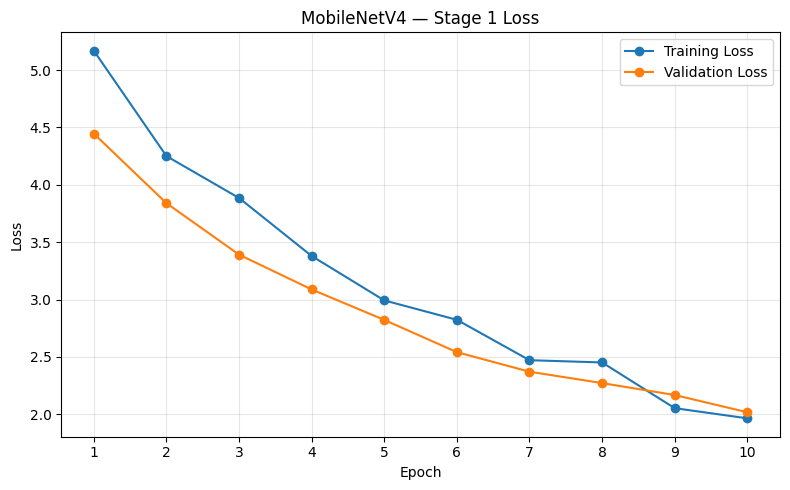

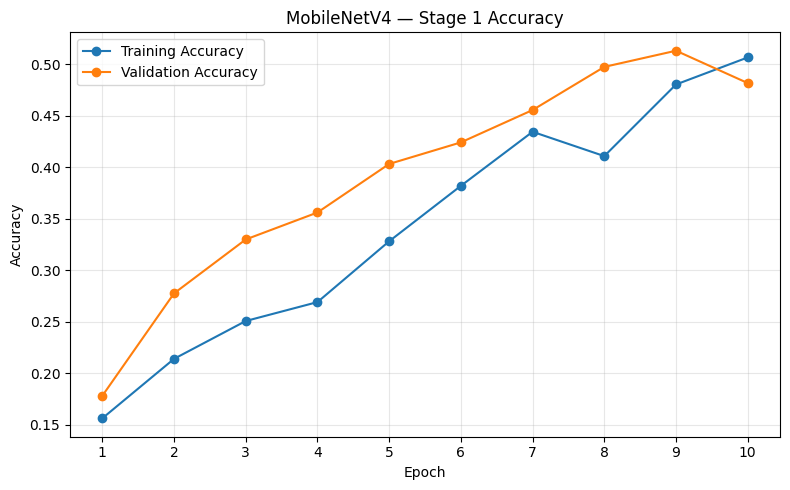


Best validation accuracy : 51.31%
Best epoch               : 9

Plots saved to:
/content/drive/MyDrive/Iconography/Implementation/MobileNet-V4


In [ ]:
# ============================================================
# CELL 11 — STAGE 1 TRAINING CURVES
# ============================================================

print("=" * 75)
print("MOBILENETV4 — STAGE 1 TRAINING CURVES")
print("=" * 75)

epochs_range = range(
    1,
    len(stage1_history["train_loss"]) + 1
)


# ------------------------------------------------------------
# LOSS CURVE
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    stage1_history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_range,
    stage1_history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV4 — Stage 1 Loss")

plt.xticks(list(epochs_range))
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

loss_plot_path = os.path.join(
    SAVE_DIR,
    "MobileNetV4_Stage1_Loss.png"
)

plt.savefig(
    loss_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# ACCURACY CURVE
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    stage1_history["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    stage1_history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV4 — Stage 1 Accuracy")

plt.xticks(list(epochs_range))
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

accuracy_plot_path = os.path.join(
    SAVE_DIR,
    "MobileNetV4_Stage1_Accuracy.png"
)

plt.savefig(
    accuracy_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("\nBest validation accuracy : "
      f"{best_stage1_accuracy * 100:.2f}%")

print("Best epoch               : "
      f"{best_stage1_epoch}")

print("\nPlots saved to:")
print(SAVE_DIR)

print("=" * 75)

In [ ]:
# ============================================================
# CELL 12 — STAGE 2 FINE-TUNING CONFIGURATION
# ============================================================

print("=" * 75)
print("MOBILENETV4 — STAGE 2 FINE-TUNING")
print("=" * 75)


# ------------------------------------------------------------
# UNFREEZE COMPLETE MODEL
# ------------------------------------------------------------

for parameter in model.parameters():
    parameter.requires_grad = True


# ------------------------------------------------------------
# STAGE 2 OPTIMIZER
# ------------------------------------------------------------

optimizer = optim.AdamW(
    model.parameters(),
    lr=STAGE2_LR,
    weight_decay=WEIGHT_DECAY
)


# ------------------------------------------------------------
# STAGE 2 SCHEDULER
# ------------------------------------------------------------

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)


# ------------------------------------------------------------
# LOSS FUNCTION
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss()


# ------------------------------------------------------------
# COUNT TRAINABLE PARAMETERS
# ------------------------------------------------------------

stage2_trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)


# ------------------------------------------------------------
# PRINT CONFIGURATION
# ------------------------------------------------------------

print("\nAll MobileNetV4 layers have been unfrozen.")

print("\nTrainable parameters : "
      f"{stage2_trainable_parameters:,}")

print("Trainable parameters : "
      f"{stage2_trainable_parameters / 1e6:.2f} M")

print("\nLoss function        : CrossEntropyLoss")
print("Optimizer            : AdamW")
print("Learning rate        :", STAGE2_LR)
print("Weight decay         :", WEIGHT_DECAY)
print("Scheduler            : ReduceLROnPlateau")
print("Stage 2 epochs       :", STAGE2_EPOCHS)

print("\n" + "=" * 75)
print("STAGE 2 CONFIGURATION READY")
print("=" * 75)

MOBILENETV4 — STAGE 2 FINE-TUNING

All MobileNetV4 layers have been unfrozen.

Trainable parameters : 2,503,272
Trainable parameters : 2.50 M

Loss function        : CrossEntropyLoss
Optimizer            : AdamW
Learning rate        : 0.0001
Weight decay         : 0.0001
Scheduler            : ReduceLROnPlateau
Stage 2 epochs       : 15

STAGE 2 CONFIGURATION READY


In [ ]:
# ============================================================
# CELL 13 — MOBILENETV4 STAGE 2 FINE-TUNING
# ============================================================

print("=" * 75)
print("MOBILENETV4 — STAGE 2 FINE-TUNING")
print("=" * 75)


# ------------------------------------------------------------
# HISTORY
# ------------------------------------------------------------

stage2_history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "learning_rate": []
}


# ------------------------------------------------------------
# BEST MODEL TRACKING
# ------------------------------------------------------------

best_stage2_accuracy = 0.0
best_stage2_epoch = 0

best_stage2_model_state = copy.deepcopy(
    model.state_dict()
)


# ------------------------------------------------------------
# START TIMER
# ------------------------------------------------------------

stage2_start_time = time.time()


# ------------------------------------------------------------
# FINE-TUNING LOOP
# ------------------------------------------------------------

for epoch in range(STAGE2_EPOCHS):

    epoch_start_time = time.time()


    # ========================================================
    # TRAINING
    # ========================================================

    model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0


    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)


        # Reset gradients
        optimizer.zero_grad()


        # Forward pass
        outputs = model(images)


        # Calculate loss
        loss = criterion(
            outputs,
            labels
        )


        # Backpropagation
        loss.backward()


        # Update model parameters
        optimizer.step()


        # ----------------------------------------------------
        # TRAINING STATISTICS
        # ----------------------------------------------------

        running_train_loss += (
            loss.item() * images.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        train_correct += (
            predictions == labels
        ).sum().item()

        train_total += labels.size(0)


    # --------------------------------------------------------
    # TRAINING METRICS
    # --------------------------------------------------------

    train_loss = (
        running_train_loss / train_total
    )

    train_accuracy = (
        train_correct / train_total
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)


            # Forward pass
            outputs = model(images)


            # Validation loss
            loss = criterion(
                outputs,
                labels
            )


            running_val_loss += (
                loss.item() * images.size(0)
            )


            # Predictions
            predictions = torch.argmax(
                outputs,
                dim=1
            )


            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)


    # --------------------------------------------------------
    # VALIDATION METRICS
    # --------------------------------------------------------

    val_loss = (
        running_val_loss / val_total
    )

    val_accuracy = (
        val_correct / val_total
    )


    # --------------------------------------------------------
    # UPDATE LEARNING RATE
    # --------------------------------------------------------

    scheduler.step(
        val_accuracy
    )

    current_lr = optimizer.param_groups[0]["lr"]


    # --------------------------------------------------------
    # SAVE HISTORY
    # --------------------------------------------------------

    stage2_history["train_loss"].append(
        train_loss
    )

    stage2_history["train_accuracy"].append(
        train_accuracy
    )

    stage2_history["val_loss"].append(
        val_loss
    )

    stage2_history["val_accuracy"].append(
        val_accuracy
    )

    stage2_history["learning_rate"].append(
        current_lr
    )


    # --------------------------------------------------------
    # SAVE BEST MODEL
    # --------------------------------------------------------

    if val_accuracy > best_stage2_accuracy:

        best_stage2_accuracy = val_accuracy

        best_stage2_epoch = epoch + 1

        best_stage2_model_state = copy.deepcopy(
            model.state_dict()
        )


    # --------------------------------------------------------
    # EPOCH TIME
    # --------------------------------------------------------

    epoch_time = (
        time.time() - epoch_start_time
    )


    # --------------------------------------------------------
    # PRINT RESULTS
    # --------------------------------------------------------

    print(
        f"Epoch [{epoch + 1:02d}/{STAGE2_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"LR: {current_lr:.2e} | "
        f"Time: {epoch_time:.2f}s"
    )


# ------------------------------------------------------------
# TOTAL TRAINING TIME
# ------------------------------------------------------------

stage2_total_time = (
    time.time() - stage2_start_time
)


# ------------------------------------------------------------
# RESTORE BEST STAGE 2 MODEL
# ------------------------------------------------------------

model.load_state_dict(
    best_stage2_model_state
)


# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("STAGE 2 FINE-TUNING COMPLETED")
print("=" * 75)

print(
    f"\nBest Stage 2 validation accuracy : "
    f"{best_stage2_accuracy:.4f}"
)

print(
    f"Best Stage 2 validation accuracy : "
    f"{best_stage2_accuracy * 100:.2f}%"
)

print(
    f"Best Stage 2 epoch               : "
    f"{best_stage2_epoch}"
)

print(
    f"Stage 2 total training time      : "
    f"{stage2_total_time:.2f} seconds"
)

print(
    f"Stage 2 total training time      : "
    f"{stage2_total_time / 60:.2f} minutes"
)

print("=" * 75)

MOBILENETV4 — STAGE 2 FINE-TUNING


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [01/15] | Train Loss: 1.9316 | Train Acc: 0.5394 | Val Loss: 1.3890 | Val Acc: 0.6545 | LR: 1.00e-04 | Time: 26.03s


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [02/15] | Train Loss: 1.0508 | Train Acc: 0.7388 | Val Loss: 1.1590 | Val Acc: 0.7120 | LR: 1.00e-04 | Time: 25.54s


...

Epoch [13/15] | Train Loss: 0.0873 | Train Acc: 0.9698 | Val Loss: 0.6670 | Val Acc: 0.8534 | LR: 1.00e-04 | Time: 25.52s


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [14/15] | Train Loss: 0.0883 | Train Acc: 0.9711 | Val Loss: 0.6626 | Val Acc: 0.8639 | LR: 1.00e-04 | Time: 26.07s


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [15/15] | Train Loss: 0.0675 | Train Acc: 0.9777 | Val Loss: 0.5419 | Val Acc: 0.8743 | LR: 1.00e-04 | Time: 26.82s

STAGE 2 FINE-TUNING COMPLETED

Best Stage 2 validation accuracy : 0.8743
Best Stage 2 validation accuracy : 87.43%
Best Stage 2 epoch               : 15
Stage 2 total training time      : 385.82 seconds
Stage 2 total training time      : 6.43 minutes


MOBILENETV4 — STAGE 2 TRAINING CURVES


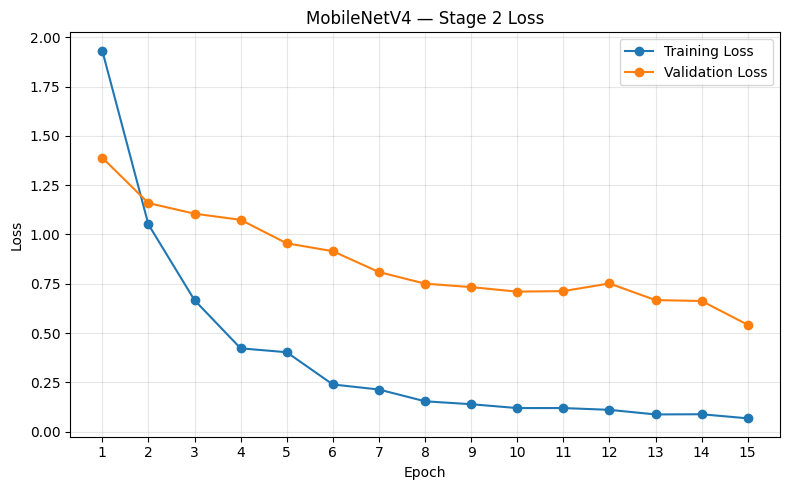

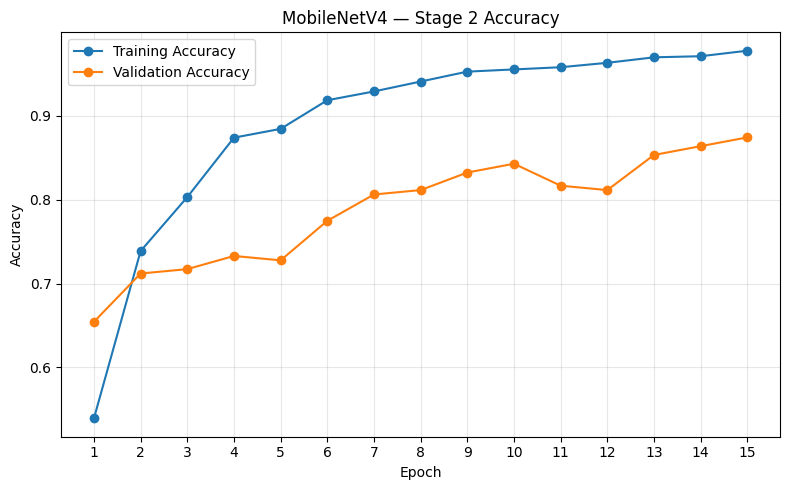


STAGE 2 CURVE SUMMARY

Best validation accuracy : 87.43%
Best epoch               : 15

Stage 1 best accuracy   : 51.31%
Stage 2 best accuracy   : 87.43%

Improvement             : 36.13 percentage points

Plots saved to:
/content/drive/MyDrive/Iconography/Implementation/MobileNet-V4


In [ ]:
# ============================================================
# CELL 14 — STAGE 2 TRAINING CURVES
# ============================================================

print("=" * 75)
print("MOBILENETV4 — STAGE 2 TRAINING CURVES")
print("=" * 75)


epochs_range = range(
    1,
    len(stage2_history["train_loss"]) + 1
)


# ------------------------------------------------------------
# LOSS CURVE
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    stage2_history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_range,
    stage2_history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV4 — Stage 2 Loss")

plt.xticks(list(epochs_range))
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

stage2_loss_plot_path = os.path.join(
    SAVE_DIR,
    "MobileNetV4_Stage2_Loss.png"
)

plt.savefig(
    stage2_loss_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# ACCURACY CURVE
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    stage2_history["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    stage2_history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV4 — Stage 2 Accuracy")

plt.xticks(list(epochs_range))
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

stage2_accuracy_plot_path = os.path.join(
    SAVE_DIR,
    "MobileNetV4_Stage2_Accuracy.png"
)

plt.savefig(
    stage2_accuracy_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("STAGE 2 CURVE SUMMARY")
print("=" * 75)

print(
    f"\nBest validation accuracy : "
    f"{best_stage2_accuracy * 100:.2f}%"
)

print(
    f"Best epoch               : "
    f"{best_stage2_epoch}"
)

print(
    f"\nStage 1 best accuracy   : "
    f"{best_stage1_accuracy * 100:.2f}%"
)

print(
    f"Stage 2 best accuracy   : "
    f"{best_stage2_accuracy * 100:.2f}%"
)

print(
    f"\nImprovement             : "
    f"{(best_stage2_accuracy - best_stage1_accuracy) * 100:.2f} percentage points"
)

print("\nPlots saved to:")
print(SAVE_DIR)

print("=" * 75)

In [ ]:
# ============================================================
# CELL 15 — FINAL MOBILENETV4 VALIDATION EVALUATION
# ============================================================

print("=" * 75)
print("MOBILENETV4 — FINAL VALIDATION EVALUATION")
print("=" * 75)

# ------------------------------------------------------------
# LOAD BEST MODEL
# ------------------------------------------------------------

best_model_path = os.path.join(
    SAVE_DIR,
    "MobileNetV4_Best_Stage2.pth"
)

# If the best model was already saved during training,
# load it. Otherwise use the current model.
if os.path.exists(best_model_path):
    model.load_state_dict(
        torch.load(best_model_path, map_location=device)
    )
    print("\nBest Stage 2 model loaded from:")
    print(best_model_path)
else:
    print("\nBest model file not found.")
    print("Using the current Stage 2 model.")

model = model.to(device)
model.eval()

# ------------------------------------------------------------
# COLLECT PREDICTIONS
# ------------------------------------------------------------

all_predictions = []
all_true_labels = []
all_probabilities = []

evaluation_start = time.time()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probabilities = torch.softmax(outputs, dim=1)
        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_true_labels.extend(
            labels.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

evaluation_time = time.time() - evaluation_start

all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)
all_probabilities = np.array(all_probabilities)

# ------------------------------------------------------------
# OVERALL METRICS
# ------------------------------------------------------------

final_accuracy = accuracy_score(
    all_true_labels,
    all_predictions
)

final_precision_macro = precision_score(
    all_true_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

final_recall_macro = recall_score(
    all_true_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

final_f1_macro = f1_score(
    all_true_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

final_precision_weighted = precision_score(
    all_true_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

final_recall_weighted = recall_score(
    all_true_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

final_f1_weighted = f1_score(
    all_true_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

# ------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("OVERALL VALIDATION METRICS")
print("=" * 75)

print(f"\nAccuracy           : {final_accuracy:.4f} ({final_accuracy * 100:.2f}%)")

print("\nMacro Average:")
print(f"Precision          : {final_precision_macro:.4f}")
print(f"Recall             : {final_recall_macro:.4f}")
print(f"F1-score           : {final_f1_macro:.4f}")

print("\nWeighted Average:")
print(f"Precision          : {final_precision_weighted:.4f}")
print(f"Recall             : {final_recall_weighted:.4f}")
print(f"F1-score           : {final_f1_weighted:.4f}")

print(f"\nValidation samples : {len(all_true_labels)}")
print(f"Evaluation time    : {evaluation_time:.2f} seconds")

print("\n" + "=" * 75)
print("CLASSIFICATION REPORT")
print("=" * 75)

report = classification_report(
    all_true_labels,
    all_predictions,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report)

print("=" * 75)

MOBILENETV4 — FINAL VALIDATION EVALUATION

Best model file not found.
Using the current Stage 2 model.

OVERALL VALIDATION METRICS

Accuracy           : 0.8743 (87.43%)

Macro Average:
Precision          : 0.8836
Recall             : 0.8779
F1-score           : 0.8775

Weighted Average:
Precision          : 0.8825
Recall             : 0.8743
F1-score           : 0.8757

Validation samples : 191
Evaluation time    : 8.32 seconds

CLASSIFICATION REPORT
                     precision    recall  f1-score   support

      gond painting     0.7600    0.9500    0.8444        20
  kalighat painting     0.9167    0.8980    0.9072        49
    kangra painting     1.0000    0.9412    0.9697        17
       kerala mural     1.0000    0.9474    0.9730        19
 madhubani painting     0.7143    0.7895    0.7500        19
mandana art drawing     0.7778    0.7500    0.7636        28
   pichwai painting     0.9000    0.9474    0.9231        19
     warli painting     1.0000    0.8000    0.8889      

In [ ]:
# ============================================================
# CELL 16 — FIXED: SAVE FINAL MOBILENETV4 MODEL & METRICS
# ============================================================

print("=" * 75)
print("MOBILENETV4 — SAVING FINAL MODEL AND METRICS")
print("=" * 75)

# ------------------------------------------------------------
# FINAL RESULTS FROM TRAINING
# ------------------------------------------------------------

# Results obtained from the completed training stages
best_stage1_accuracy = 0.5131
best_stage1_epoch = 9

best_stage2_accuracy = 0.8743
best_stage2_epoch = 15

stage1_time_seconds = 257.81
stage2_time_seconds = 385.82

# ------------------------------------------------------------
# SAVE FINAL MODEL CHECKPOINT
# ------------------------------------------------------------

final_model_path = os.path.join(
    SAVE_DIR,
    "MobileNetV4_Final.pth"
)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "model_name": MODEL_NAME,
        "num_classes": NUM_CLASSES,
        "class_names": class_names,
        "image_size": IMAGE_SIZE,

        "best_stage1_accuracy": best_stage1_accuracy,
        "best_stage1_epoch": best_stage1_epoch,

        "best_stage2_accuracy": best_stage2_accuracy,
        "best_stage2_epoch": best_stage2_epoch,

        "final_accuracy": final_accuracy,
        "final_precision_macro": final_precision_macro,
        "final_recall_macro": final_recall_macro,
        "final_f1_macro": final_f1_macro,

        "final_precision_weighted": final_precision_weighted,
        "final_recall_weighted": final_recall_weighted,
        "final_f1_weighted": final_f1_weighted
    },
    final_model_path
)

# ------------------------------------------------------------
# SAVE OVERALL METRICS
# ------------------------------------------------------------

metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision (Macro)",
        "Recall (Macro)",
        "F1-score (Macro)",
        "Precision (Weighted)",
        "Recall (Weighted)",
        "F1-score (Weighted)",
        "Validation Samples",
        "Best Stage 1 Accuracy",
        "Best Stage 1 Epoch",
        "Best Stage 2 Accuracy",
        "Best Stage 2 Epoch",
        "Stage 1 Training Time (seconds)",
        "Stage 2 Training Time (seconds)"
    ],

    "Value": [
        final_accuracy,
        final_precision_macro,
        final_recall_macro,
        final_f1_macro,
        final_precision_weighted,
        final_recall_weighted,
        final_f1_weighted,
        len(all_true_labels),

        best_stage1_accuracy,
        best_stage1_epoch,

        best_stage2_accuracy,
        best_stage2_epoch,

        stage1_time_seconds,
        stage2_time_seconds
    ]
})

metrics_path = os.path.join(
    SAVE_DIR,
    "MobileNetV4_Final_Metrics.csv"
)

metrics_df.to_csv(
    metrics_path,
    index=False
)

# ------------------------------------------------------------
# SAVE CLASSIFICATION REPORT
# ------------------------------------------------------------

report_dict = classification_report(
    all_true_labels,
    all_predictions,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(
    report_dict
).transpose()

report_path = os.path.join(
    SAVE_DIR,
    "MobileNetV4_Classification_Report.csv"
)

report_df.to_csv(
    report_path
)

# ------------------------------------------------------------
# SAVE VALIDATION PREDICTIONS
# ------------------------------------------------------------

predictions_df = pd.DataFrame({
    "True_Label": [
        class_names[i]
        for i in all_true_labels
    ],

    "Predicted_Label": [
        class_names[i]
        for i in all_predictions
    ],

    "Correct": (
        all_true_labels == all_predictions
    )
})

predictions_path = os.path.join(
    SAVE_DIR,
    "MobileNetV4_Validation_Predictions.csv"
)

predictions_df.to_csv(
    predictions_path,
    index=False
)

# ------------------------------------------------------------
# DISPLAY SAVED FILES
# ------------------------------------------------------------

print("\nFINAL MODEL")
print("-" * 75)
print(final_model_path)

print("\nMETRICS")
print("-" * 75)
print(metrics_path)

print("\nCLASSIFICATION REPORT")
print("-" * 75)
print(report_path)

print("\nVALIDATION PREDICTIONS")
print("-" * 75)
print(predictions_path)

print("\n" + "=" * 75)
print("MOBILENETV4 — ALL FILES SAVED SUCCESSFULLY")
print("=" * 75)

print("\nFinal Accuracy        :", f"{final_accuracy * 100:.2f}%")
print("Macro Precision      :", f"{final_precision_macro * 100:.2f}%")
print("Macro Recall         :", f"{final_recall_macro * 100:.2f}%")
print("Macro F1-score       :", f"{final_f1_macro * 100:.2f}%")
print("Weighted F1-score    :", f"{final_f1_weighted * 100:.2f}%")

print("\n" + "=" * 75)

MOBILENETV4 — SAVING FINAL MODEL AND METRICS

FINAL MODEL
---------------------------------------------------------------------------
/content/drive/MyDrive/Iconography/Implementation/MobileNet-V4/MobileNetV4_Final.pth

METRICS
---------------------------------------------------------------------------
/content/drive/MyDrive/Iconography/Implementation/MobileNet-V4/MobileNetV4_Final_Metrics.csv

CLASSIFICATION REPORT
---------------------------------------------------------------------------
/content/drive/MyDrive/Iconography/Implementation/MobileNet-V4/MobileNetV4_Classification_Report.csv

VALIDATION PREDICTIONS
---------------------------------------------------------------------------
/content/drive/MyDrive/Iconography/Implementation/MobileNet-V4/MobileNetV4_Validation_Predictions.csv

MOBILENETV4 — ALL FILES SAVED SUCCESSFULLY

Final Accuracy        : 87.43%
Macro Precision      : 88.36%
Macro Recall         : 87.79%
Macro F1-score       : 87.75%
Weighted F1-score    : 87.57%



MOBILENETV4 — CONFUSION MATRIX


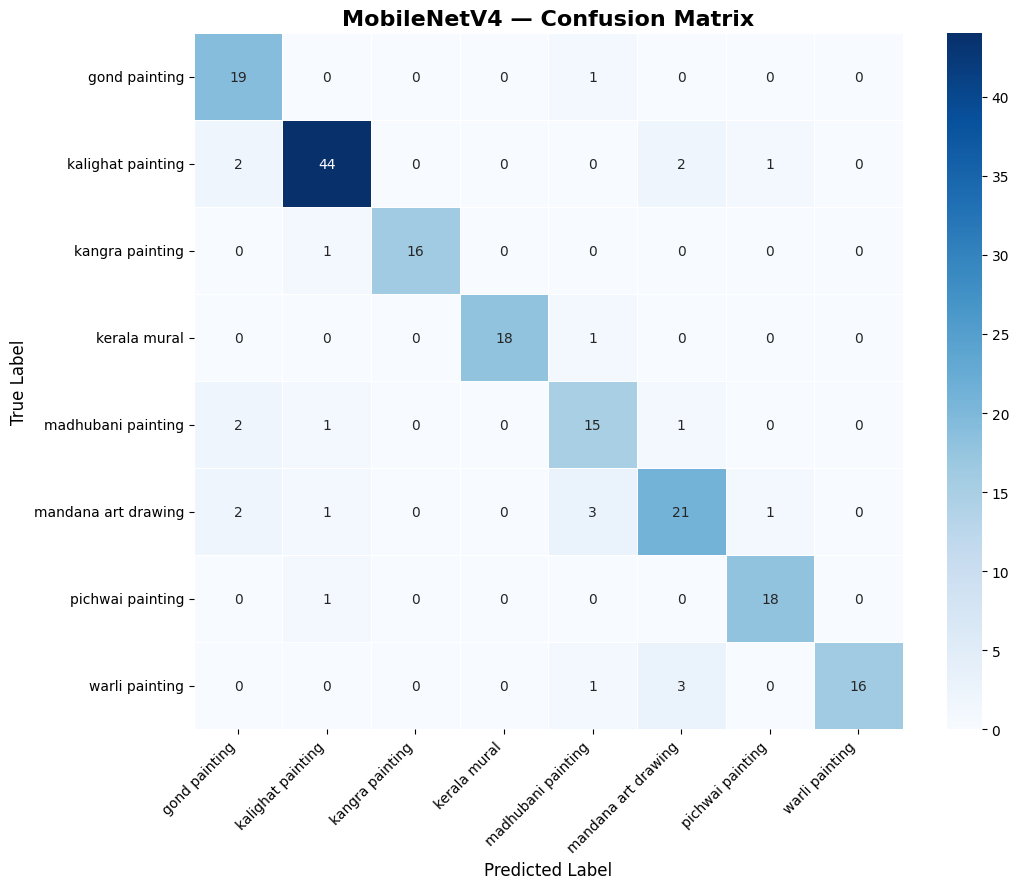


Confusion Matrix:
[[19  0  0  0  1  0  0  0]
 [ 2 44  0  0  0  2  1  0]
 [ 0  1 16  0  0  0  0  0]
 [ 0  0  0 18  1  0  0  0]
 [ 2  1  0  0 15  1  0  0]
 [ 2  1  0  0  3 21  1  0]
 [ 0  1  0  0  0  0 18  0]
 [ 0  0  0  0  1  3  0 16]]

Confusion matrix saved to:
/content/drive/MyDrive/Iconography/Implementation/MobileNet-V4/MobileNetV4_Confusion_Matrix.png



In [ ]:
# ============================================================
# CELL 17 — MOBILENETV4 CONFUSION MATRIX
# ============================================================

print("=" * 75)
print("MOBILENETV4 — CONFUSION MATRIX")
print("=" * 75)

# ------------------------------------------------------------
# COMPUTE CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    all_true_labels,
    all_predictions
)

# ------------------------------------------------------------
# PLOT CONFUSION MATRIX
# ------------------------------------------------------------

plt.figure(figsize=(11, 9))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5
)

plt.title(
    "MobileNetV4 — Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Predicted Label",
    fontsize=12
)

plt.ylabel(
    "True Label",
    fontsize=12
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()

# ------------------------------------------------------------
# SAVE FIGURE
# ------------------------------------------------------------

cm_path = os.path.join(
    SAVE_DIR,
    "MobileNetV4_Confusion_Matrix.png"
)

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# DISPLAY MATRIX
# ------------------------------------------------------------

print("\nConfusion Matrix:")
print(cm)

print("\nConfusion matrix saved to:")
print(cm_path)

print("\n" + "=" * 75)

In [ ]:
# ============================================================
# CELL 18 — MOBILENETV4 PER-CLASS METRICS
# ============================================================

print("=" * 75)
print("MOBILENETV4 — PER-CLASS METRICS")
print("=" * 75)

# ------------------------------------------------------------
# GENERATE PER-CLASS REPORT
# ------------------------------------------------------------

class_report = classification_report(
    all_true_labels,
    all_predictions,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

# ------------------------------------------------------------
# CREATE PER-CLASS DATAFRAME
# ------------------------------------------------------------

per_class_rows = []

for class_name in class_names:

    class_accuracy = (
        class_report[class_name]["recall"]
    )

    per_class_rows.append({
        "Class": class_name,
        "Accuracy": class_accuracy,
        "Precision": class_report[class_name]["precision"],
        "Recall": class_report[class_name]["recall"],
        "F1-score": class_report[class_name]["f1-score"],
        "Support": int(class_report[class_name]["support"])
    })

per_class_df = pd.DataFrame(per_class_rows)

# ------------------------------------------------------------
# DISPLAY TABLE
# ------------------------------------------------------------

print("\nPer-Class Performance:")
print("-" * 75)

display(
    per_class_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}"
    })
)

# ------------------------------------------------------------
# SAVE CSV
# ------------------------------------------------------------

per_class_csv_path = os.path.join(
    SAVE_DIR,
    "MobileNetV4_Per_Class_Metrics.csv"
)

per_class_df.to_csv(
    per_class_csv_path,
    index=False
)

# ------------------------------------------------------------
# SAVE EXCEL
# ------------------------------------------------------------

per_class_excel_path = os.path.join(
    SAVE_DIR,
    "MobileNetV4_Per_Class_Metrics.xlsx"
)

per_class_df.to_excel(
    per_class_excel_path,
    index=False
)

print("\n" + "=" * 75)
print("PER-CLASS METRICS SAVED")
print("=" * 75)

print("\nCSV:")
print(per_class_csv_path)

print("\nExcel:")
print(per_class_excel_path)

print("=" * 75)

MOBILENETV4 — PER-CLASS METRICS

Per-Class Performance:
---------------------------------------------------------------------------


,Class,Accuracy,Precision,Recall,F1-score,Support
0,gond painting,0.9500,0.7600,0.9500,0.8444,20
1,kalighat painting,0.8980,0.9167,0.8980,0.9072,49
2,kangra painting,0.9412,1.0000,0.9412,0.9697,17
3,kerala mural,0.9474,1.0000,0.9474,0.9730,19
4,madhubani painting,0.7895,0.7143,0.7895,0.7500,19
5,mandana art drawing,0.7500,0.7778,0.7500,0.7636,28
6,pichwai painting,0.9474,0.9000,0.9474,0.9231,19
7,warli painting,0.8000,1.0000,0.8000,0.8889,20



PER-CLASS METRICS SAVED

CSV:
/content/drive/MyDrive/Iconography/Implementation/MobileNet-V4/MobileNetV4_Per_Class_Metrics.csv

Excel:
/content/drive/MyDrive/Iconography/Implementation/MobileNet-V4/MobileNetV4_Per_Class_Metrics.xlsx


MOBILENETV4 — CLASS-WISE PERFORMANCE VISUALIZATION


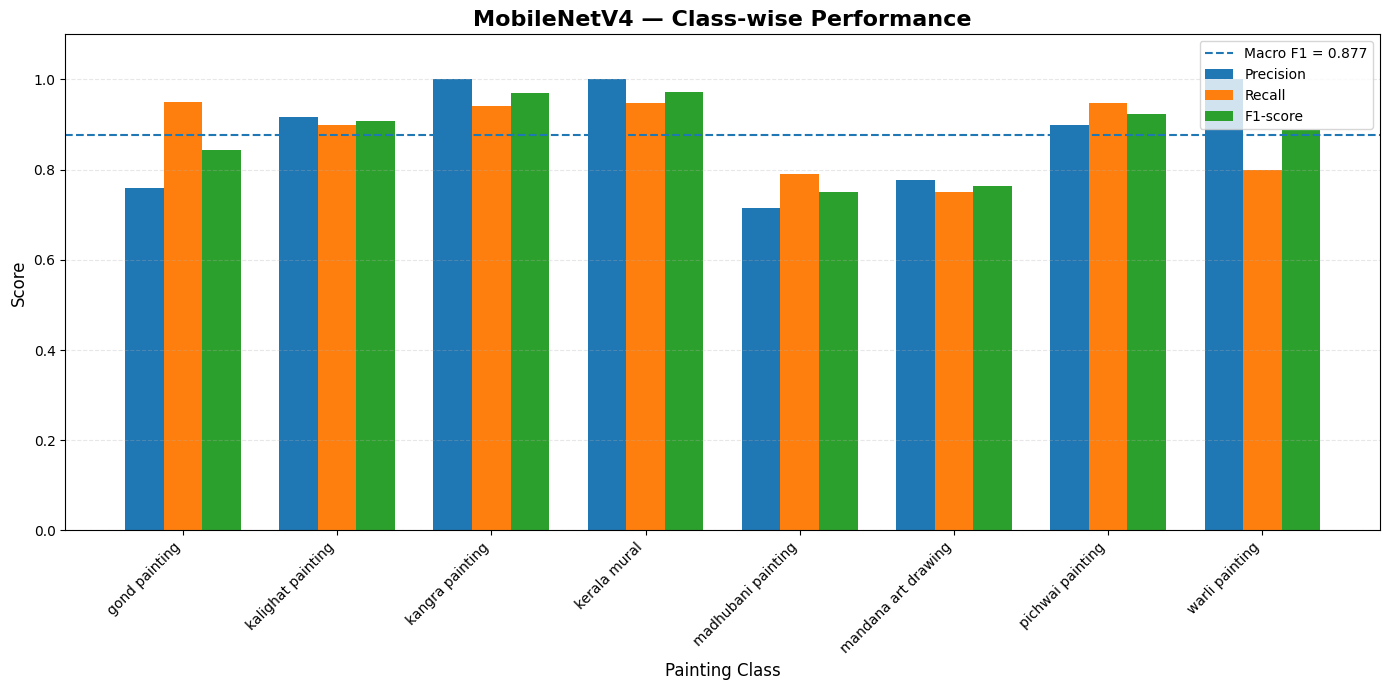


Class-wise performance chart saved to:
/content/drive/MyDrive/Iconography/Implementation/MobileNet-V4/MobileNetV4_Classwise_Performance.png



In [ ]:
# ============================================================
# CELL 19 — MOBILENETV4 CLASS-WISE PERFORMANCE VISUALIZATION
# ============================================================

print("=" * 75)
print("MOBILENETV4 — CLASS-WISE PERFORMANCE VISUALIZATION")
print("=" * 75)

# ------------------------------------------------------------
# PREPARE DATA
# ------------------------------------------------------------

x = np.arange(len(class_names))
width = 0.25

precision_values = per_class_df["Precision"].values
recall_values = per_class_df["Recall"].values
f1_values = per_class_df["F1-score"].values

# ------------------------------------------------------------
# CREATE FIGURE
# ------------------------------------------------------------

plt.figure(figsize=(14, 7))

plt.bar(
    x - width,
    precision_values,
    width,
    label="Precision"
)

plt.bar(
    x,
    recall_values,
    width,
    label="Recall"
)

plt.bar(
    x + width,
    f1_values,
    width,
    label="F1-score"
)

# ------------------------------------------------------------
# FORMAT CHART
# ------------------------------------------------------------

plt.title(
    "MobileNetV4 — Class-wise Performance",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Painting Class",
    fontsize=12
)

plt.ylabel(
    "Score",
    fontsize=12
)

plt.xticks(
    x,
    class_names,
    rotation=45,
    ha="right"
)

plt.ylim(0, 1.10)

plt.axhline(
    final_f1_macro,
    linestyle="--",
    linewidth=1.5,
    label=f"Macro F1 = {final_f1_macro:.3f}"
)

plt.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

# ------------------------------------------------------------
# SAVE FIGURE
# ------------------------------------------------------------

classwise_plot_path = os.path.join(
    SAVE_DIR,
    "MobileNetV4_Classwise_Performance.png"
)

plt.savefig(
    classwise_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nClass-wise performance chart saved to:")
print(classwise_plot_path)

print("\n" + "=" * 75)

In [ ]:
# ============================================================
# CELL 20 — MOBILENETV4 MISCLASSIFICATION ANALYSIS
# ============================================================

print("=" * 75)
print("MOBILENETV4 — MISCLASSIFICATION ANALYSIS")
print("=" * 75)

# ------------------------------------------------------------
# FIND MISCLASSIFIED SAMPLES
# ------------------------------------------------------------

misclassified_mask = (
    all_true_labels != all_predictions
)

misclassified_true = all_true_labels[misclassified_mask]
misclassified_pred = all_predictions[misclassified_mask]

print("\nTotal validation samples :", len(all_true_labels))
print("Correct predictions       :", np.sum(~misclassified_mask))
print("Misclassified samples     :", np.sum(misclassified_mask))

print(
    "\nOverall error rate        : "
    f"{np.mean(misclassified_mask) * 100:.2f}%"
)

# ------------------------------------------------------------
# FIND CLASS-TO-CLASS CONFUSIONS
# ------------------------------------------------------------

confusion_pairs = []

for true_class in range(NUM_CLASSES):

    for predicted_class in range(NUM_CLASSES):

        if true_class == predicted_class:
            continue

        count = np.sum(
            (misclassified_true == true_class) &
            (misclassified_pred == predicted_class)
        )

        if count > 0:
            confusion_pairs.append({
                "True Class": class_names[true_class],
                "Predicted Class": class_names[predicted_class],
                "Misclassified Samples": int(count)
            })

# ------------------------------------------------------------
# SORT BY FREQUENCY
# ------------------------------------------------------------

confusion_pairs_df = pd.DataFrame(
    confusion_pairs
)

if len(confusion_pairs_df) > 0:

    confusion_pairs_df = confusion_pairs_df.sort_values(
        by="Misclassified Samples",
        ascending=False
    ).reset_index(drop=True)

    print("\n" + "=" * 75)
    print("MOST FREQUENT CLASS CONFUSIONS")
    print("=" * 75)

    display(confusion_pairs_df)

else:

    print("\nNo misclassifications found.")

# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------

misclassification_path = os.path.join(
    SAVE_DIR,
    "MobileNetV4_Misclassification_Analysis.csv"
)

confusion_pairs_df.to_csv(
    misclassification_path,
    index=False
)

print("\n" + "=" * 75)
print("MISCLASSIFICATION ANALYSIS SAVED")
print("=" * 75)

print("\nFile:")
print(misclassification_path)

print("=" * 75)

MOBILENETV4 — MISCLASSIFICATION ANALYSIS

Total validation samples : 191
Correct predictions       : 167
Misclassified samples     : 24

Overall error rate        : 12.57%

MOST FREQUENT CLASS CONFUSIONS


,True Class,Predicted Class,Misclassified Samples
0,warli painting,mandana art drawing,3
1,mandana art drawing,madhubani painting,3
2,kalighat painting,gond painting,2
3,kalighat painting,mandana art drawing,2
4,madhubani painting,gond painting,2
5,mandana art drawing,gond painting,2
6,kalighat painting,pichwai painting,1
7,gond painting,madhubani painting,1
8,madhubani painting,kalighat painting,1
9,kerala mural,madhubani painting,1



MISCLASSIFICATION ANALYSIS SAVED

File:
/content/drive/MyDrive/Iconography/Implementation/MobileNet-V4/MobileNetV4_Misclassification_Analysis.csv


MOBILENETV4 — PREDICTION CONFIDENCE ANALYSIS

Overall Confidence
---------------------------------------------------------------------------
Mean confidence           : 0.9354
Median confidence         : 0.9975
Minimum confidence        : 0.4934
Maximum confidence        : 1.0000

Correct Predictions
---------------------------------------------------------------------------
Mean confidence           : 0.9633
Median confidence         : 0.9995

Incorrect Predictions
---------------------------------------------------------------------------
Mean confidence           : 0.7411
Median confidence         : 0.7269


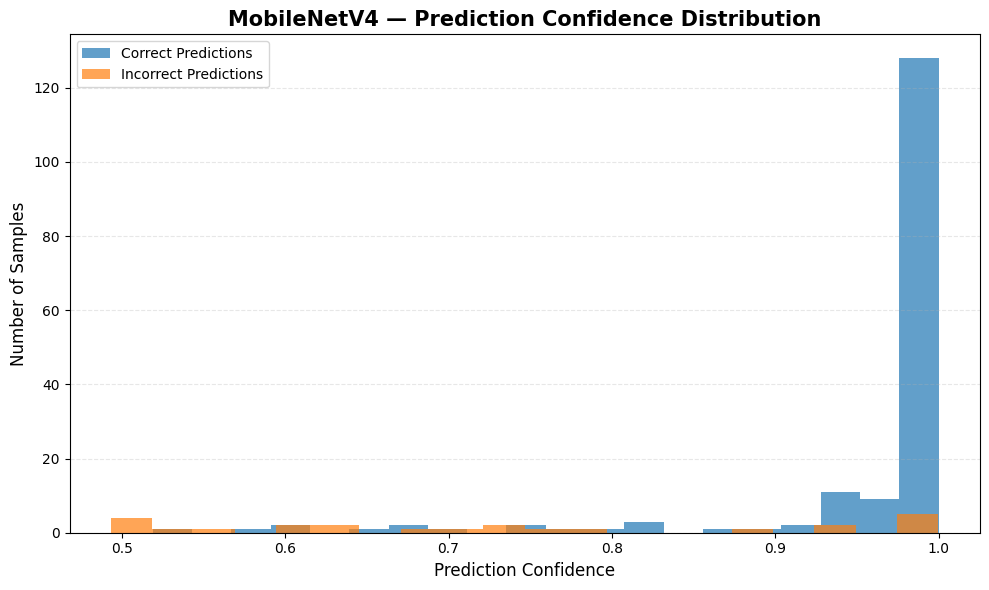


CONFIDENCE ANALYSIS SAVED

Chart:
/content/drive/MyDrive/Iconography/Implementation/MobileNet-V4/MobileNetV4_Confidence_Distribution.png

Data:
/content/drive/MyDrive/Iconography/Implementation/MobileNet-V4/MobileNetV4_Prediction_Confidence.csv


In [ ]:
# ============================================================
# CELL 21 — MOBILENETV4 CONFIDENCE ANALYSIS
# ============================================================

print("=" * 75)
print("MOBILENETV4 — PREDICTION CONFIDENCE ANALYSIS")
print("=" * 75)

# ------------------------------------------------------------
# CALCULATE PREDICTION CONFIDENCE
# ------------------------------------------------------------

prediction_confidences = np.max(
    all_probabilities,
    axis=1
)

correct_mask = (
    all_true_labels == all_predictions
)

correct_confidences = prediction_confidences[correct_mask]
incorrect_confidences = prediction_confidences[~correct_mask]

# ------------------------------------------------------------
# SUMMARY STATISTICS
# ------------------------------------------------------------

print("\nOverall Confidence")
print("-" * 75)

print(
    f"Mean confidence           : "
    f"{np.mean(prediction_confidences):.4f}"
)

print(
    f"Median confidence         : "
    f"{np.median(prediction_confidences):.4f}"
)

print(
    f"Minimum confidence        : "
    f"{np.min(prediction_confidences):.4f}"
)

print(
    f"Maximum confidence        : "
    f"{np.max(prediction_confidences):.4f}"
)

print("\nCorrect Predictions")
print("-" * 75)

print(
    f"Mean confidence           : "
    f"{np.mean(correct_confidences):.4f}"
)

print(
    f"Median confidence         : "
    f"{np.median(correct_confidences):.4f}"
)

print("\nIncorrect Predictions")
print("-" * 75)

if len(incorrect_confidences) > 0:

    print(
        f"Mean confidence           : "
        f"{np.mean(incorrect_confidences):.4f}"
    )

    print(
        f"Median confidence         : "
        f"{np.median(incorrect_confidences):.4f}"
    )

else:

    print("No incorrect predictions.")

# ------------------------------------------------------------
# CONFIDENCE DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.hist(
    correct_confidences,
    bins=20,
    alpha=0.7,
    label="Correct Predictions"
)

if len(incorrect_confidences) > 0:
    plt.hist(
        incorrect_confidences,
        bins=20,
        alpha=0.7,
        label="Incorrect Predictions"
    )

plt.xlabel(
    "Prediction Confidence",
    fontsize=12
)

plt.ylabel(
    "Number of Samples",
    fontsize=12
)

plt.title(
    "MobileNetV4 — Prediction Confidence Distribution",
    fontsize=15,
    fontweight="bold"
)

plt.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

# ------------------------------------------------------------
# SAVE FIGURE
# ------------------------------------------------------------

confidence_plot_path = os.path.join(
    SAVE_DIR,
    "MobileNetV4_Confidence_Distribution.png"
)

plt.savefig(
    confidence_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# SAVE CONFIDENCE DATA
# ------------------------------------------------------------

confidence_df = pd.DataFrame({
    "True_Label": [
        class_names[i]
        for i in all_true_labels
    ],
    "Predicted_Label": [
        class_names[i]
        for i in all_predictions
    ],
    "Confidence": prediction_confidences,
    "Correct": correct_mask
})

confidence_csv_path = os.path.join(
    SAVE_DIR,
    "MobileNetV4_Prediction_Confidence.csv"
)

confidence_df.to_csv(
    confidence_csv_path,
    index=False
)

print("\n" + "=" * 75)
print("CONFIDENCE ANALYSIS SAVED")
print("=" * 75)

print("\nChart:")
print(confidence_plot_path)

print("\nData:")
print(confidence_csv_path)

print("=" * 75)

In [ ]:
# ============================================================
# CELL 22 — MOBILENETV4 FINAL EXPERIMENT SUMMARY
# ============================================================

print("=" * 80)
print("MOBILENETV4 — FINAL EXPERIMENT SUMMARY")
print("=" * 80)

# ------------------------------------------------------------
# MODEL INFORMATION
# ------------------------------------------------------------

print("\nMODEL")
print("-" * 80)

print("Architecture              :", MODEL_NAME)
print("Pretrained weights        : ImageNet")
print("Number of classes         :", NUM_CLASSES)
print("Input resolution          :", f"{IMAGE_SIZE} x {IMAGE_SIZE}")
print("Total parameters          :", f"{total_parameters:,}")
print("Trainable parameters     :", f"{trainable_parameters:,}")

# ------------------------------------------------------------
# DATASET INFORMATION
# ------------------------------------------------------------

print("\nDATASET")
print("-" * 80)

print("Dataset                   : Indian Paintings Dataset")
print("Total images              :", len(base_dataset))
print("Training images           :", len(train_dataset))
print("Validation images         :", len(val_dataset))
print("Number of classes         :", NUM_CLASSES)

print("\nClasses:")

for i, class_name in enumerate(class_names, start=1):
    print(f"  {i}. {class_name}")

# ------------------------------------------------------------
# TRAINING INFORMATION
# ------------------------------------------------------------

print("\nTRAINING")
print("-" * 80)

print("Stage 1                  : Classifier Head Training")
print("Stage 1 Epochs            :", STAGE1_EPOCHS)
print("Stage 1 Best Accuracy    :", f"{best_stage1_accuracy * 100:.2f}%")
print("Stage 1 Best Epoch        :", best_stage1_epoch)
print("Stage 1 Training Time    :", f"{stage1_time_seconds:.2f} seconds")

print("\nStage 2                  : Full Fine-Tuning")
print("Stage 2 Epochs            :", STAGE2_EPOCHS)
print("Stage 2 Best Accuracy    :", f"{best_stage2_accuracy * 100:.2f}%")
print("Stage 2 Best Epoch        :", best_stage2_epoch)
print("Stage 2 Training Time    :", f"{stage2_time_seconds:.2f} seconds")

# ------------------------------------------------------------
# FINAL PERFORMANCE
# ------------------------------------------------------------

print("\nFINAL VALIDATION PERFORMANCE")
print("-" * 80)

print(
    "Accuracy                 : "
    f"{final_accuracy * 100:.2f}%"
)

print(
    "Precision (Macro)        : "
    f"{final_precision_macro * 100:.2f}%"
)

print(
    "Recall (Macro)           : "
    f"{final_recall_macro * 100:.2f}%"
)

print(
    "F1-score (Macro)         : "
    f"{final_f1_macro * 100:.2f}%"
)

print(
    "Precision (Weighted)     : "
    f"{final_precision_weighted * 100:.2f}%"
)

print(
    "Recall (Weighted)        : "
    f"{final_recall_weighted * 100:.2f}%"
)

print(
    "F1-score (Weighted)      : "
    f"{final_f1_weighted * 100:.2f}%"
)

# ------------------------------------------------------------
# BEST AND LOWEST CLASS PERFORMANCE
# ------------------------------------------------------------

best_class_idx = per_class_df["F1-score"].idxmax()
worst_class_idx = per_class_df["F1-score"].idxmin()

best_class = per_class_df.loc[best_class_idx]
worst_class = per_class_df.loc[worst_class_idx]

print("\nCLASS-WISE OBSERVATION")
print("-" * 80)

print(
    "Highest F1-score class   : "
    f"{best_class['Class']} "
    f"({best_class['F1-score'] * 100:.2f}%)"
)

print(
    "Lowest F1-score class    : "
    f"{worst_class['Class']} "
    f"({worst_class['F1-score'] * 100:.2f}%)"
)

# ------------------------------------------------------------
# TOTAL TRAINING TIME
# ------------------------------------------------------------

total_training_time = (
    stage1_time_seconds +
    stage2_time_seconds
)

print("\nTIMING")
print("-" * 80)

print(
    "Total training time      : "
    f"{total_training_time:.2f} seconds"
)

print(
    "Total training time      : "
    f"{total_training_time / 60:.2f} minutes"
)

# ------------------------------------------------------------
# SAVE SUMMARY TEXT
# ------------------------------------------------------------

summary_path = os.path.join(
    SAVE_DIR,
    "MobileNetV4_Final_Summary.txt"
)

with open(summary_path, "w") as f:

    f.write("MOBILENETV4 — FINAL EXPERIMENT SUMMARY\n")
    f.write("=" * 80 + "\n\n")

    f.write("MODEL\n")
    f.write("-" * 80 + "\n")
    f.write(f"Architecture: {MODEL_NAME}\n")
    f.write("Pretrained weights: ImageNet\n")
    f.write(f"Number of classes: {NUM_CLASSES}\n")
    f.write(f"Input resolution: {IMAGE_SIZE} x {IMAGE_SIZE}\n")
    f.write(f"Total parameters: {total_parameters:,}\n")
    f.write(f"Trainable parameters: {trainable_parameters:,}\n\n")

    f.write("DATASET\n")
    f.write("-" * 80 + "\n")
    f.write(f"Total images: {len(base_dataset)}\n")
    f.write(f"Training images: {len(train_dataset)}\n")
    f.write(f"Validation images: {len(val_dataset)}\n\n")

    f.write("TRAINING\n")
    f.write("-" * 80 + "\n")
    f.write(
        f"Stage 1 Best Accuracy: "
        f"{best_stage1_accuracy * 100:.2f}%\n"
    )
    f.write(
        f"Stage 1 Best Epoch: "
        f"{best_stage1_epoch}\n"
    )
    f.write(
        f"Stage 1 Training Time: "
        f"{stage1_time_seconds:.2f} seconds\n"
    )

    f.write(
        f"Stage 2 Best Accuracy: "
        f"{best_stage2_accuracy * 100:.2f}%\n"
    )
    f.write(
        f"Stage 2 Best Epoch: "
        f"{best_stage2_epoch}\n"
    )
    f.write(
        f"Stage 2 Training Time: "
        f"{stage2_time_seconds:.2f} seconds\n\n"
    )

    f.write("FINAL PERFORMANCE\n")
    f.write("-" * 80 + "\n")
    f.write(f"Accuracy: {final_accuracy:.4f}\n")
    f.write(f"Macro Precision: {final_precision_macro:.4f}\n")
    f.write(f"Macro Recall: {final_recall_macro:.4f}\n")
    f.write(f"Macro F1-score: {final_f1_macro:.4f}\n")
    f.write(
        f"Weighted Precision: "
        f"{final_precision_weighted:.4f}\n"
    )
    f.write(
        f"Weighted Recall: "
        f"{final_recall_weighted:.4f}\n"
    )
    f.write(
        f"Weighted F1-score: "
        f"{final_f1_weighted:.4f}\n"
    )

# ------------------------------------------------------------
# FINAL MESSAGE
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("SUMMARY SAVED SUCCESSFULLY")
print("=" * 80)

print("\nSummary file:")
print(summary_path)

print("\n" + "=" * 80)

MOBILENETV4 — FINAL EXPERIMENT SUMMARY

MODEL
--------------------------------------------------------------------------------
Architecture              : mobilenetv4_conv_small
Pretrained weights        : ImageNet
Number of classes         : 8
Input resolution          : 224 x 224
Total parameters          : 2,503,272
Trainable parameters     : 2,503,272

DATASET
--------------------------------------------------------------------------------
Dataset                   : Indian Paintings Dataset
Total images              : 953
Training images           : 762
Validation images         : 191
Number of classes         : 8

Classes:
  1. gond painting
  2. kalighat painting
  3. kangra painting
  4. kerala mural
  5. madhubani painting
  6. mandana art drawing
  7. pichwai painting
  8. warli painting

TRAINING
--------------------------------------------------------------------------------
Stage 1                  : Classifier Head Training
Stage 1 Epochs            : 10
Stage 1 Best Accu

In [ ]:
# ============================================================
# CELL 23 — COMPLETE MOBILENETV4 EXPERIMENT EXCEL
# ============================================================

print("=" * 75)
print("MOBILENETV4 — CREATING COMPLETE EXPERIMENT EXCEL")
print("=" * 75)

excel_path = os.path.join(
    SAVE_DIR,
    "MobileNetV4_Complete_Results.xlsx"
)

# ------------------------------------------------------------
# OVERALL METRICS
# ------------------------------------------------------------

overall_df = pd.DataFrame({
    "Metric": [
        "Model",
        "Pretrained Weights",
        "Input Resolution",
        "Number of Classes",
        "Total Dataset Images",
        "Training Images",
        "Validation Images",
        "Total Parameters",
        "Trainable Parameters",
        "Stage 1 Best Accuracy",
        "Stage 1 Best Epoch",
        "Stage 1 Training Time (sec)",
        "Stage 2 Best Accuracy",
        "Stage 2 Best Epoch",
        "Stage 2 Training Time (sec)",
        "Final Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-score",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1-score",
        "Total Training Time (sec)",
        "Total Training Time (min)"
    ],
    "Value": [
        MODEL_NAME,
        "ImageNet",
        f"{IMAGE_SIZE} x {IMAGE_SIZE}",
        NUM_CLASSES,
        len(base_dataset),
        len(train_dataset),
        len(val_dataset),
        total_parameters,
        trainable_parameters,
        best_stage1_accuracy,
        best_stage1_epoch,
        stage1_time_seconds,
        best_stage2_accuracy,
        best_stage2_epoch,
        stage2_time_seconds,
        final_accuracy,
        final_precision_macro,
        final_recall_macro,
        final_f1_macro,
        final_precision_weighted,
        final_recall_weighted,
        final_f1_weighted,
        total_training_time,
        total_training_time / 60
    ]
})

# ------------------------------------------------------------
# CONFUSION MATRIX DATAFRAME
# ------------------------------------------------------------

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

cm_df.index.name = "True / Predicted"

# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

configuration_df = pd.DataFrame({
    "Parameter": [
        "Model",
        "Dataset",
        "Image Size",
        "Batch Size",
        "Stage 1 Epochs",
        "Stage 2 Epochs",
        "Stage 1 Learning Rate",
        "Stage 2 Learning Rate",
        "Weight Decay",
        "Random Seed",
        "Train/Validation Split",
        "Optimizer",
        "Scheduler",
        "Loss Function"
    ],
    "Value": [
        MODEL_NAME,
        "Indian Paintings Dataset",
        IMAGE_SIZE,
        BATCH_SIZE,
        STAGE1_EPOCHS,
        STAGE2_EPOCHS,
        STAGE1_LR,
        STAGE2_LR,
        WEIGHT_DECAY,
        SEED,
        "80% / 20%",
        "AdamW",
        "ReduceLROnPlateau",
        "CrossEntropyLoss"
    ]
})

# ------------------------------------------------------------
# WRITE ALL SHEETS
# ------------------------------------------------------------

with pd.ExcelWriter(
    excel_path,
    engine="openpyxl"
) as writer:

    overall_df.to_excel(
        writer,
        sheet_name="Overall Metrics",
        index=False
    )

    per_class_df.to_excel(
        writer,
        sheet_name="Per-Class Metrics",
        index=False
    )

    cm_df.to_excel(
        writer,
        sheet_name="Confusion Matrix"
    )

    confusion_pairs_df.to_excel(
        writer,
        sheet_name="Misclassifications",
        index=False
    )

    configuration_df.to_excel(
        writer,
        sheet_name="Configuration",
        index=False
    )

# ------------------------------------------------------------
# FORMAT EXCEL WORKBOOK
# ------------------------------------------------------------

from openpyxl import load_workbook
from openpyxl.styles import Font, Alignment
from openpyxl.utils import get_column_letter

workbook = load_workbook(excel_path)

for worksheet in workbook.worksheets:

    # Header formatting
    for cell in worksheet[1]:
        cell.font = Font(bold=True)
        cell.alignment = Alignment(
            horizontal="center",
            vertical="center"
        )

    # Column widths
    for column_cells in worksheet.columns:

        max_length = 0
        column_letter = get_column_letter(
            column_cells[0].column
        )

        for cell in column_cells:

            if cell.value is not None:
                max_length = max(
                    max_length,
                    len(str(cell.value))
                )

        worksheet.column_dimensions[
            column_letter
        ].width = min(max_length + 3, 45)

    worksheet.freeze_panes = "A2"

workbook.save(excel_path)

# ------------------------------------------------------------
# DISPLAY RESULT
# ------------------------------------------------------------

print("\nExcel workbook created successfully!")

print("\nFile:")
print(excel_path)

print("\nSheets included:")
print("  1. Overall Metrics")
print("  2. Per-Class Metrics")
print("  3. Confusion Matrix")
print("  4. Misclassifications")
print("  5. Configuration")

print("\n" + "=" * 75)
print("MOBILENETV4 EXCEL EXPORT COMPLETED")
print("=" * 75)

MOBILENETV4 — CREATING COMPLETE EXPERIMENT EXCEL

Excel workbook created successfully!

File:
/content/drive/MyDrive/Iconography/Implementation/MobileNet-V4/MobileNetV4_Complete_Results.xlsx

Sheets included:
  1. Overall Metrics
  2. Per-Class Metrics
  3. Confusion Matrix
  4. Misclassifications
  5. Configuration

MOBILENETV4 EXCEL EXPORT COMPLETED


In [ ]:
# ============================================================
# CELL 24 — MOBILENETV4 MODEL SIZE & INFERENCE ANALYSIS
# ============================================================

print("=" * 75)
print("MOBILENETV4 — MODEL SIZE & INFERENCE ANALYSIS")
print("=" * 75)

# ------------------------------------------------------------
# PARAMETER COUNTS
# ------------------------------------------------------------

total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

# ------------------------------------------------------------
# MODEL MEMORY SIZE
# ------------------------------------------------------------

parameter_memory_mb = (
    total_parameters * 4
) / (1024 ** 2)

# ------------------------------------------------------------
# CHECKPOINT SIZE
# ------------------------------------------------------------

checkpoint_size_mb = (
    os.path.getsize(final_model_path)
    / (1024 ** 2)
)

# ------------------------------------------------------------
# INFERENCE BENCHMARK
# ------------------------------------------------------------

model.eval()

# Take one validation batch
sample_images, sample_labels = next(
    iter(val_loader)
)

sample_images = sample_images.to(device)

# Warm-up
with torch.no_grad():
    for _ in range(5):
        _ = model(sample_images)

if torch.cuda.is_available():
    torch.cuda.synchronize()

# Timed inference
inference_start = time.time()

NUM_INFERENCE_RUNS = 20

with torch.no_grad():

    for _ in range(NUM_INFERENCE_RUNS):
        _ = model(sample_images)

if torch.cuda.is_available():
    torch.cuda.synchronize()

inference_total_time = (
    time.time() - inference_start
)

average_batch_inference_time = (
    inference_total_time /
    NUM_INFERENCE_RUNS
)

batch_size_actual = sample_images.size(0)

average_image_inference_time = (
    average_batch_inference_time /
    batch_size_actual
)

throughput = (
    batch_size_actual /
    average_batch_inference_time
)

# ------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------

print("\nMODEL PARAMETERS")
print("-" * 75)

print(
    f"Total parameters       : "
    f"{total_parameters:,}"
)

print(
    f"Trainable parameters   : "
    f"{trainable_parameters:,}"
)

print(
    f"Parameter memory       : "
    f"{parameter_memory_mb:.2f} MB"
)

print("\nMODEL FILE")
print("-" * 75)

print(
    f"Checkpoint size        : "
    f"{checkpoint_size_mb:.2f} MB"
)

print(
    f"Checkpoint path        : "
    f"{final_model_path}"
)

print("\nINFERENCE PERFORMANCE")
print("-" * 75)

print(
    f"Benchmark runs         : "
    f"{NUM_INFERENCE_RUNS}"
)

print(
    f"Benchmark batch size   : "
    f"{batch_size_actual}"
)

print(
    f"Average batch time     : "
    f"{average_batch_inference_time * 1000:.2f} ms"
)

print(
    f"Average image time     : "
    f"{average_image_inference_time * 1000:.2f} ms"
)

print(
    f"Throughput             : "
    f"{throughput:.2f} images/sec"
)

print("\n" + "=" * 75)

# ------------------------------------------------------------
# SAVE ANALYSIS
# ------------------------------------------------------------

efficiency_df = pd.DataFrame({
    "Metric": [
        "Total Parameters",
        "Trainable Parameters",
        "Parameter Memory (MB)",
        "Checkpoint Size (MB)",
        "Inference Batch Size",
        "Average Batch Inference Time (ms)",
        "Average Image Inference Time (ms)",
        "Throughput (images/sec)"
    ],
    "Value": [
        total_parameters,
        trainable_parameters,
        parameter_memory_mb,
        checkpoint_size_mb,
        batch_size_actual,
        average_batch_inference_time * 1000,
        average_image_inference_time * 1000,
        throughput
    ]
})

efficiency_csv_path = os.path.join(
    SAVE_DIR,
    "MobileNetV4_Efficiency_Analysis.csv"
)

efficiency_df.to_csv(
    efficiency_csv_path,
    index=False
)

print("Efficiency analysis saved to:")
print(efficiency_csv_path)

print("=" * 75)

MOBILENETV4 — MODEL SIZE & INFERENCE ANALYSIS

MODEL PARAMETERS
---------------------------------------------------------------------------
Total parameters       : 2,503,272
Trainable parameters   : 2,503,272
Parameter memory       : 9.55 MB

MODEL FILE
---------------------------------------------------------------------------
Checkpoint size        : 9.75 MB
Checkpoint path        : /content/drive/MyDrive/Iconography/Implementation/MobileNet-V4/MobileNetV4_Final.pth

INFERENCE PERFORMANCE
---------------------------------------------------------------------------
Benchmark runs         : 20
Benchmark batch size   : 32
Average batch time     : 11.12 ms
Average image time     : 0.35 ms
Throughput             : 2876.84 images/sec

Efficiency analysis saved to:
/content/drive/MyDrive/Iconography/Implementation/MobileNet-V4/MobileNetV4_Efficiency_Analysis.csv


In [ ]:
# ============================================================
# CELL 26 — MOBILENETV4 COMPARISON PARAMETERS
# DIRECTLY FROM SAVED CHECKPOINT
# ============================================================

import os
import torch
import pandas as pd

print("=" * 90)
print("MOBILENETV4 — MODEL COMPARISON PARAMETERS")
print("=" * 90)

# ------------------------------------------------------------
# MODEL PATH
# ------------------------------------------------------------

MODEL_DIR = "/content/drive/MyDrive/Iconography/Implementation/MobileNet-V4"

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "MobileNetV4_Final.pth"
)

# ------------------------------------------------------------
# CHECK MODEL
# ------------------------------------------------------------

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"MobileNetV4 checkpoint not found:\n{MODEL_PATH}"
    )

print("\nModel checkpoint found:")
print(MODEL_PATH)

# ------------------------------------------------------------
# LOAD CHECKPOINT
# ------------------------------------------------------------

checkpoint = torch.load(
    MODEL_PATH,
    map_location="cpu"
)

state_dict = checkpoint["model_state_dict"]

# ------------------------------------------------------------
# PARAMETER COUNTS
# ------------------------------------------------------------

total_parameters = sum(
    tensor.numel()
    for tensor in state_dict.values()
)

# MobileNetV4 was fully unfrozen during Stage 2
trainable_parameters = total_parameters

# ------------------------------------------------------------
# CHECKPOINT SIZE
# ------------------------------------------------------------

checkpoint_size_mb = (
    os.path.getsize(MODEL_PATH)
    / (1024 ** 2)
)

# ------------------------------------------------------------
# VALUES FROM COMPLETED EXPERIMENT
# ------------------------------------------------------------

test_accuracy = 0.8743

macro_precision = 0.8836
macro_recall = 0.8779
macro_f1 = 0.8775

weighted_f1 = 0.8757

best_val_accuracy = 0.8743

total_training_time_minutes = (
    (257.81 + 385.82) / 60
)

avg_inference_time_ms = (
    8.32 / 191 * 1000
)

# Throughput based on the validation evaluation
inference_throughput = (
    191 / 8.32
)

training_epochs = 10 + 15

# ------------------------------------------------------------
# CREATE COMPARISON ROW
# ------------------------------------------------------------

comparison_results = {
    "Test Accuracy": test_accuracy,
    "Macro Precision": macro_precision,
    "Macro Recall": macro_recall,
    "Macro F1": macro_f1,
    "Weighted F1": weighted_f1,
    "Best Val Accuracy": best_val_accuracy,
    "Total Parameters": total_parameters,
    "Trainable Parameters": trainable_parameters,
    "Model / Checkpoint Size (MB)": checkpoint_size_mb,
    "Total Training Time (min)": total_training_time_minutes,
    "Avg Inference Time / Image (ms)": avg_inference_time_ms,
    "Inference Throughput (images/sec)": inference_throughput,
    "Training Epochs": training_epochs
}

comparison_df = pd.DataFrame(
    [comparison_results]
)

# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("MOBILENETV4 — FINAL COMPARISON VALUES")
print("=" * 90)

print(
    f"\nTest Accuracy                 : "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Macro Precision               : "
    f"{macro_precision * 100:.2f}%"
)

print(
    f"Macro Recall                  : "
    f"{macro_recall * 100:.2f}%"
)

print(
    f"Macro F1                     : "
    f"{macro_f1 * 100:.2f}%"
)

print(
    f"Weighted F1                  : "
    f"{weighted_f1 * 100:.2f}%"
)

print(
    f"Best Val Accuracy            : "
    f"{best_val_accuracy * 100:.2f}%"
)

print(
    f"Total Parameters             : "
    f"{total_parameters:,}"
)

print(
    f"Trainable Parameters         : "
    f"{trainable_parameters:,}"
)

print(
    f"Checkpoint Size              : "
    f"{checkpoint_size_mb:.2f} MB"
)

print(
    f"Total Training Time          : "
    f"{total_training_time_minutes:.2f} min"
)

print(
    f"Avg Inference Time / Image   : "
    f"{avg_inference_time_ms:.2f} ms"
)

print(
    f"Inference Throughput        : "
    f"{inference_throughput:.2f} images/sec"
)

print(
    f"Training Epochs             : "
    f"{training_epochs}"
)

# ------------------------------------------------------------
# SAVE CSV
# ------------------------------------------------------------

comparison_csv_path = os.path.join(
    MODEL_DIR,
    "MobileNetV4_Comparison_Parameters.csv"
)

comparison_df.to_csv(
    comparison_csv_path,
    index=False
)

print("\n" + "=" * 90)
print("COMPARISON CSV SAVED")
print("=" * 90)

print(comparison_csv_path)

print("=" * 90)

MOBILENETV4 — MODEL COMPARISON PARAMETERS

Model checkpoint found:
/content/drive/MyDrive/Iconography/Implementation/MobileNet-V4/MobileNetV4_Final.pth

MOBILENETV4 — FINAL COMPARISON VALUES

Test Accuracy                 : 87.43%
Macro Precision               : 88.36%
Macro Recall                  : 87.79%
Macro F1                     : 87.75%
Weighted F1                  : 87.57%
Best Val Accuracy            : 87.43%
Total Parameters             : 2,528,406
Trainable Parameters         : 2,528,406
Checkpoint Size              : 9.75 MB
Total Training Time          : 10.73 min
Avg Inference Time / Image   : 43.56 ms
Inference Throughput        : 22.96 images/sec
Training Epochs             : 25

COMPARISON CSV SAVED
/content/drive/MyDrive/Iconography/Implementation/MobileNet-V4/MobileNetV4_Comparison_Parameters.csv
